# E-commerce Product Analytics: Funnel, Retention & Customer Behavior Analysis

### Analyzing 170M+ behavioral events to understand purchase behavior, cart-to-purchase progression, retention, customer segments, and product opportunities.

## Executive Summary

This project analyzes a large-scale e-commerce behavioral dataset from the Synerise RecSys Challenge 2025 to understand how customers move from shopping intent to purchase, how purchasing behavior develops over time, and which behavioral patterns are associated with repeat engagement.

The analysis focuses on four major product questions:

1. **Customer behavior:** How frequently do customers purchase, return, and expand across products?
2. **Cart-to-purchase funnel:** How often is an add-to-cart customer-SKU pair followed by a later purchase of the same SKU?
3. **Retention:** How does weekly purchasing activity change after a customer's first purchase?
4. **Behavioral segmentation:** What distinguishes one-time purchasers from deeper returning customers?

### Key Findings

- **744,980** customers made at least one observed purchase.
- **65.35%** were single-occasion, single-product customers.
- Only **20.88%** purchased on multiple calendar days during the observation window.
- The observed **cart-to-later-same-SKU purchase rate was 20.06%**.
- Among converting cart pairs, the median time from first cart event to later purchase was approximately **6.9 minutes**.
- Weekly purchase retention declined sharply early in the customer lifecycle and stabilized around a smaller recurring base.
- **94.62% of returning customers were multi-product customers.**
- **98.87% of returning multi-product customers purchased at least one new SKU after their first purchase day.**

### Product Opportunities Identified

The analysis highlights four areas for further product investigation:

- improving **second-purchase activation**,
- reducing **cart-to-purchase friction**,
- prioritizing **high-volume categories with below-benchmark conversion**,
- encouraging **cross-product expansion among returning customers**.

Because the dataset is observational and anonymized, these findings identify product opportunities and testable hypotheses rather than causal conclusions.

## Business Problem

E-commerce teams need to understand not only whether customers purchase, but how customers progress from shopping intent to purchase, whether they return after their first purchase, and which behavioral patterns are associated with deeper engagement.

This project uses anonymized e-commerce event data to examine customer purchasing behavior across the observed period and identify areas where product teams could investigate opportunities to improve conversion, retention, and cross-product engagement.

Because the dataset does not contain explicit order IDs, cart IDs, session IDs, actual monetary prices, or known purchase quantities, the analysis focuses on observable customer-product behavior rather than traditional revenue or order-level metrics.

## Analytical Questions

1. **Customer behavior**
   - How many customers purchase only once versus across multiple purchase occasions or days?
   - How many different products do customers purchase?
   - How quickly do returning customers make their first return purchase?
   - How long does observed purchasing activity persist?

2. **Cart-to-purchase progression**
   - How many customers appear in both add-to-cart and purchase activity?
   - At the customer-SKU level, how often is a cart event followed by a later purchase of the same SKU?
   - How quickly does purchase occur after the first observed cart event?
   - Where does observed cart-to-purchase drop-off occur?

3. **Category-level funnel performance**
   - How does cart-to-purchase performance vary across product categories?
   - Which high-volume categories have below-benchmark observed conversion?
   - Which categories combine meaningful scale with the largest benchmark conversion gaps?

4. **Retention**
   - How does weekly purchasing activity change after a customer's first purchase?
   - What proportion of customers are active again in Week 1, Week 2, Week 4, Week 8, and Week 12?
   - Is the largest retention decline concentrated early in the customer lifecycle?

5. **Behavioral segmentation**
   - What distinct purchasing patterns exist among one-day and returning customers?
   - How do single-product and multi-product returners differ?
   - Do returning multi-product customers expand into products that were not purchased on their first purchase day?

6. **Product opportunities**
   - Which observed behaviors suggest opportunities for second-purchase activation?
   - Where could cart-to-purchase friction be investigated?
   - Which categories may deserve targeted funnel analysis?
   - Could cross-product discovery be tested as a way to deepen repeat engagement?

## Dataset and Methodology

### Dataset

This project uses the anonymized e-commerce behavioral dataset from the **Synerise RecSys Challenge 2025**.

The dataset contains several types of customer interaction events stored in Parquet files:

| File | Main fields | Purpose |
|---|---|---|
| `add_to_cart.parquet` | `client_id`, `timestamp`, `sku` | Product add-to-cart events |
| `remove_from_cart.parquet` | `client_id`, `timestamp`, `sku` | Product removal events |
| `product_buy.parquet` | `client_id`, `timestamp`, `sku` | Purchase events |
| `page_visit.parquet` | `client_id`, `timestamp`, `url` | Page visit events |
| `search_query.parquet` | `client_id`, `timestamp`, `query` | Search activity |
| `product_properties.parquet` | `sku`, `category`, `price`, `name` | Product metadata |

The raw dataset contains more than **170 million behavioral events**, with `page_visit` accounting for the majority of rows.

The main analysis in this project focuses on:

- purchase events,
- add-to-cart events,
- product metadata,
- customer-level purchase behavior,
- customer-SKU funnel behavior,
- weekly cohort activity.

---

### Observation Period

Observed purchase activity spans approximately:

**23 June 2022 to 9 November 2022**

For weekly cohort analysis, incomplete boundary weeks were excluded from the main retention calculation.

The main cohort window therefore used:

- Earliest complete cohort week: **27 June 2022**
- Latest complete activity week: **31 October 2022**

---

## Analytical Units

Different questions required different analytical units.

### 1. Purchase Event Occasion

The raw purchase table contained repeated rows with identical:

`client_id + timestamp + sku`

Because the dataset documentation does not establish whether these repeated rows represent multiple units or duplicated event logging, the analysis does not interpret them as quantity.

For behavioral analysis, purchase occasions were defined as unique:

`client_id + timestamp + sku`

Exact duplicate combinations were therefore collapsed before calculating purchase frequency and customer behavior.

---

### 2. Customer-Level Analysis

Customer behavior was summarized using metrics such as:

- purchase occasions,
- unique products purchased,
- unique purchase days,
- first purchase date,
- last purchase date,
- purchase span,
- days to first return,
- number of return days.

This level was used for behavioral segmentation and retention-related analysis.

---

### 3. Customer-SKU Pair Analysis

The dataset does not contain an explicit:

- order ID,
- cart ID,
- session ID,
- checkout ID.

Because of this, cart-to-purchase progression was measured using unique:

`client_id + sku`

pairs.

A customer-SKU pair was considered to have an observed cart-to-purchase progression when:

1. the customer added the SKU to cart, and
2. the same customer later purchased the same SKU.

This metric should therefore be interpreted as a **cart-to-later-same-SKU purchase rate**, not a traditional cart or checkout conversion rate.

---

### 4. Weekly Cohort Analysis

Customers were assigned to a cohort based on the week of their first observed purchase.

Weekly activity was measured using Monday-Sunday periods.

For each customer:

- Week 0 = first-purchase week
- Week 1 = one week after first-purchase week
- Week 2 = two weeks after
- etc.

Retention was defined as the share of the original cohort that made at least one purchase during a later cohort week.

This is **periodic weekly retention**, meaning customers can return in a later week even if they were inactive in earlier weeks.

---

## Key Methodological Decisions

### Exact purchase duplicates

Exact repeated purchase rows were retained in the raw dataset but collapsed into unique purchase-event combinations for behavioral analysis.

This avoids assuming that repeated identical records represent product quantity.

### Missing values

Purchase and product metadata tables used in the main analysis were checked for missing values and referential integrity.

No missing `client_id`, `timestamp`, or `sku` values were found in the purchase table used for analysis.

### Product catalog joins

Purchase and cart SKUs were validated against the product catalog.

No missing product-category mappings were found in the analyzed cart and purchase records.

### Category volume threshold

For category-level conversion comparison, the main analysis focused on categories with at least **1,000 customer-SKU cart pairs**.

This threshold was selected to reduce instability from very small categories and to focus on categories with meaningful behavioral volume.

### Retention maturity

Later retention periods were only calculated using cohorts old enough to have the relevant observation window.

For the Week 1 to Week 12 apples-to-apples comparison, only cohorts with at least 12 weeks of observable history were used.

### Revenue limitations

The product `price` field is an anonymized price bucket rather than an actual monetary price.

Therefore, this project does not calculate:

- revenue,
- average order value,
- monetary customer lifetime value,
- profit or ROI.

The analysis focuses on behavioral engagement instead.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/add_to_cart.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/LICENSE
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/page_visit.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/remove_from_cart.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/product_properties.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/product_buy.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/search_query.parquet
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/input/relevant_clients.npy
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/target/propensity_category.npy
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/target/propensity_sku.npy
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/target/popularity_propensity_sku.npy
/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge/target/active_clien

## 1. Data Understanding and Quality

### 1.1 Dataset Structure

Before calculating customer or product metrics, the dataset structure, table sizes, schemas, and observation period were examined to understand what each event represents and which tables can be combined reliably.

In [2]:
# Imports
import pandas as pd
import pyarrow.parquet as pq

# Dataset location
data_path = "/kaggle/input/datasets/duuuscha/recsys25-synerise-challenge"

# Files
files = [
    "add_to_cart.parquet",
    "page_visit.parquet",
    "product_buy.parquet",
    "product_properties.parquet",
    "remove_from_cart.parquet",
    "search_query.parquet"
]


In [3]:
for file in files:
    parquet_file = pq.ParquetFile(f"{data_path}/{file}")
    
    print("\n" + "=" * 70)
    print(file)
    print("=" * 70)
    print("Number of rows:", parquet_file.metadata.num_rows)
    print("Number of columns:", parquet_file.metadata.num_columns)
    print("Columns:", parquet_file.schema.names)


add_to_cart.parquet
Number of rows: 5674064
Number of columns: 3
Columns: ['client_id', 'timestamp', 'sku']

page_visit.parquet
Number of rows: 156032014
Number of columns: 3
Columns: ['client_id', 'timestamp', 'url']

product_buy.parquet
Number of rows: 1775394
Number of columns: 3
Columns: ['client_id', 'timestamp', 'sku']

product_properties.parquet
Number of rows: 1260365
Number of columns: 4
Columns: ['sku', 'category', 'price', 'name']

remove_from_cart.parquet
Number of rows: 1937170
Number of columns: 3
Columns: ['client_id', 'timestamp', 'sku']

search_query.parquet
Number of rows: 10218831
Number of columns: 3
Columns: ['client_id', 'timestamp', 'query']


In [4]:
parquet_file = pq.ParquetFile(
    f"{data_path}/page_visit.parquet"
)

print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of row groups:", parquet_file.num_row_groups)

Number of rows: 156032014
Number of row groups: 149


In [5]:
batch = next(
    parquet_file.iter_batches(
        batch_size=10
    )
)

df_sample = batch.to_pandas()

df_sample

,client_id,timestamp,url
0,13083737,2022-06-23 00:10:00,7168398
1,14823465,2022-06-23 00:10:00,12455356
2,22003566,2022-06-23 00:10:00,16107006
3,3883996,2022-06-23 00:10:00,9218583
4,22003566,2022-06-23 00:10:00,16107006
5,2627532,2022-06-23 00:10:05,3821838
6,9613778,2022-06-23 00:10:05,13043130
7,13549902,2022-06-23 00:10:05,3337025
8,2576118,2022-06-23 00:10:05,11860543
9,12965754,2022-06-23 00:10:05,5768455


In [6]:
df_sample.dtypes

client_id             int64
timestamp    datetime64[ns]
url                   int64
dtype: object

In [7]:
event_files = [
    "add_to_cart.parquet",
    "product_buy.parquet",
    "remove_from_cart.parquet",
    "search_query.parquet",
    "product_properties.parquet"
]

for file in event_files:
    print("\n" + "=" * 70)
    print(file)
    print("=" * 70)
    
    parquet_file = pq.ParquetFile(f"{data_path}/{file}")
    
    batch = next(
        parquet_file.iter_batches(batch_size=10)
    )
    
    df_sample = batch.to_pandas()
    
    display(df_sample)


add_to_cart.parquet


,client_id,timestamp,sku
0,19433713,2022-06-23 00:10:20,649662
1,15811394,2022-06-23 00:11:20,615072
2,3465674,2022-06-23 00:12:20,1137565
3,23673757,2022-06-23 00:12:30,935610
4,14396191,2022-06-23 00:12:35,1359391
5,16013543,2022-06-23 00:13:25,1307134
6,15811394,2022-06-23 00:14:10,1420267
7,6411180,2022-06-23 00:14:40,250745
8,18141530,2022-06-23 00:15:10,1226113
9,15811394,2022-06-23 00:15:40,1582370



product_buy.parquet


,client_id,timestamp,sku
0,19433713,2022-06-23 00:12:15,649662
1,11106698,2022-06-23 00:12:25,965816
2,3334023,2022-06-23 00:15:25,419981
3,3334023,2022-06-23 00:15:25,1161623
4,2310948,2022-06-23 00:17:20,520725
5,13068810,2022-06-23 00:18:55,288797
6,11533389,2022-06-23 00:20:15,744753
7,19114066,2022-06-23 00:21:30,655406
8,22269508,2022-06-23 00:22:35,1051863
9,22269508,2022-06-23 00:22:35,606754



remove_from_cart.parquet


,client_id,timestamp,sku
0,16013543,2022-06-23 00:12:25,148228
1,6411180,2022-06-23 00:15:50,1321311
2,6411180,2022-06-23 00:15:55,161900
3,5943023,2022-06-23 00:20:25,376196
4,23362856,2022-06-23 00:20:50,679322
5,15811394,2022-06-23 00:20:59,1582370
6,15811394,2022-06-23 00:22:15,615072
7,15811394,2022-06-23 00:22:20,1582370
8,7795684,2022-06-23 00:24:30,760067
9,12273475,2022-06-23 00:25:35,133834



search_query.parquet


,client_id,timestamp,query
0,12965754,2022-06-23 00:10:00,[202 151 206 232 232 181 181 55 9 57 236 ...
1,12965754,2022-06-23 00:10:05,[202 151 206 232 232 181 181 55 9 57 236 ...
2,14797776,2022-06-23 00:10:05,[168 151 190 159 215 117 50 9 147 168 94 2...
3,14797776,2022-06-23 00:10:05,[168 151 190 159 215 117 50 9 147 168 94 2...
4,14797776,2022-06-23 00:10:15,[168 151 190 159 215 117 50 9 147 168 94 2...
5,14797776,2022-06-23 00:10:15,[168 151 190 159 215 117 50 9 147 168 94 2...
6,4161379,2022-06-23 00:10:25,[ 12 12 76 181 51 52 224 238 73 224 12 2...
7,995906,2022-06-23 00:10:25,[255 95 95 54 21 114 95 95 21 95 21 ...
8,3883996,2022-06-23 00:10:30,[246 246 113 246 246 246 246 119 119 219 246 1...
9,3883996,2022-06-23 00:10:30,[246 246 113 246 246 246 246 119 119 219 246 1...



product_properties.parquet


,sku,category,price,name
0,101733,6552,13,[131 245 189 142 164 164 138 254 91 83 80 1...
1,184680,6153,59,[219 48 162 96 67 72 96 44 12 250 7 2...
2,540546,618,99,[ 56 212 52 212 212 212 212 19 212 212 212 1...
3,1601877,4378,62,[164 192 102 16 237 106 83 164 53 14 193 1...
4,1022239,5158,48,[167 191 141 57 130 76 45 89 136 129 57 1...
5,981994,258,94,[253 234 133 166 71 23 120 253 139 233 180 ...
6,1070563,6329,92,[ 62 28 34 24 73 142 158 184 88 86 181 1...
7,943062,4444,28,[239 108 99 38 115 169 189 124 172 124 66 ...
8,823043,2457,28,[111 74 87 74 114 74 112 74 74 74 74 1...
9,461813,258,54,[ 59 253 10 139 65 87 179 180 86 232 162 2...


### Interpretation

The dataset contains more than 170 million behavioral events, with page visits accounting for the majority of the volume.

The core product-analysis tables contain consistent event structures based around customer identifiers, timestamps, and product identifiers. Because the page-visit table is extremely large, the project avoids loading it fully into Pandas and focuses the main behavioral analysis on purchase, cart, and product metadata events.

### 1.2 Purchase Observation Period

The purchase-event time range was checked to establish the period over which customer behavior can be observed.

In [8]:
parquet_file = pq.ParquetFile(
    f"{data_path}/product_buy.parquet"
)

print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of row groups:", parquet_file.num_row_groups)

Number of rows: 1775394
Number of row groups: 2


In [9]:
batch = next(
    parquet_file.iter_batches(batch_size=10000)
)

buy_sample = batch.to_pandas()

print("First timestamp:", buy_sample["timestamp"].min())
print("Last timestamp:", buy_sample["timestamp"].max())

First timestamp: 2022-06-23 00:12:15
Last timestamp: 2022-06-24 07:47:35


In [10]:
parquet_file = pq.ParquetFile(
    f"{data_path}/product_buy.parquet"
)

for i in range(parquet_file.num_row_groups):
    row_group = parquet_file.metadata.row_group(i)
    
    print("Row group:", i)
    
    for j in range(row_group.num_columns):
        column = row_group.column(j)
        
        print(
            column.path_in_schema,
            "min =", column.statistics.min,
            "max =", column.statistics.max
        )

Row group: 0
client_id min = 33 max = 23929160
timestamp min = 2022-06-23 00:12:15 max = 2022-09-20 17:15:10
sku min = 1 max = 1623136
Row group: 1
client_id min = 80 max = 23928901
timestamp min = 2022-09-20 17:15:10 max = 2022-11-09 23:59:35
sku min = 2 max = 1623130


In [11]:
for file in files:
    parquet_file = pq.ParquetFile(
        f"{data_path}/{file}"
    )

    print("\n" + "=" * 60)
    print(file)
    print("=" * 60)

    print("Rows:", parquet_file.metadata.num_rows)
    print("Row groups:", parquet_file.num_row_groups)

    for i in range(parquet_file.num_row_groups):
        row_group = parquet_file.metadata.row_group(i)

        for j in range(row_group.num_columns):
            column = row_group.column(j)

            if column.path_in_schema == "timestamp":
                print(
                    "Row group", i,
                    "| timestamp:",
                    column.statistics.min,
                    "→",
                    column.statistics.max
                )


add_to_cart.parquet
Rows: 5674064
Row groups: 6
Row group 0 | timestamp: 2022-06-23 00:10:20 → 2022-07-26 07:28:15
Row group 1 | timestamp: 2022-07-26 07:28:15 → 2022-08-24 14:57:10
Row group 2 | timestamp: 2022-08-24 14:57:15 → 2022-09-19 07:00:55
Row group 3 | timestamp: 2022-09-19 07:00:55 → 2022-10-11 17:07:20
Row group 4 | timestamp: 2022-10-11 17:07:20 → 2022-11-01 20:15:35
Row group 5 | timestamp: 2022-11-01 20:15:35 → 2022-11-09 23:59:55

page_visit.parquet
Rows: 156032014
Row groups: 149
Row group 0 | timestamp: 2022-06-23 00:10:00 → 2022-06-24 12:39:30
Row group 1 | timestamp: 2022-06-24 12:39:30 → 2022-06-26 08:47:05
Row group 2 | timestamp: 2022-06-26 08:47:05 → 2022-06-27 13:38:20
Row group 3 | timestamp: 2022-06-27 13:38:20 → 2022-06-28 18:48:25
Row group 4 | timestamp: 2022-06-28 18:48:25 → 2022-06-29 22:04:05
Row group 5 | timestamp: 2022-06-29 22:04:05 → 2022-07-01 07:41:30
Row group 6 | timestamp: 2022-07-01 07:41:30 → 2022-07-02 13:06:45
Row group 7 | timestamp: 202

### Interpretation

Observed purchase activity covers approximately 23 June 2022 through 9 November 2022.

This finite observation window is important for interpreting customer retention. Customers appearing near the end of the dataset have less time available to demonstrate future purchasing behavior.

### 1.3 Missing Values

Missing values were checked in the purchase fields required for customer, timing, and product-level analysis.

In [12]:
parquet_file = pq.ParquetFile(
    f"{data_path}/product_buy.parquet"
)

missing = 0
total = 0

for batch in parquet_file.iter_batches(batch_size=100_000):
    df = batch.to_pandas()
    
    missing += df.isna().sum()
    total += len(df)

print("Total rows:", total)
print("\nMissing values:")
print(missing)

Total rows: 1775394

Missing values:
client_id    0
timestamp    0
sku          0
dtype: int64


### Interpretation

No missing values were found in the `client_id`, `timestamp`, or `sku` fields used for purchase analysis.

This means purchase events can be used for customer-level and product-level grouping without introducing missing-identifier handling.

### 1.4 Repeated Purchase Records

Exact repeated purchase records were investigated before defining purchase frequency because identical customer, timestamp, and SKU records could represent either quantity or duplicated event logging.

In [13]:
buy = pq.read_table(
    f"{data_path}/product_buy.parquet"
).to_pandas()

print("Rows:", len(buy))
print("Duplicate rows:", buy.duplicated().sum())

Rows: 1775394
Duplicate rows: 283545


In [14]:
duplicates = buy[buy.duplicated(keep=False)]

print("Rows involved in duplicate groups:", len(duplicates))
print("\nSample duplicate groups:")
display(duplicates.sort_values(
    ["client_id", "timestamp", "sku"]
).head(20))

Rows involved in duplicate groups: 554936

Sample duplicate groups:


,client_id,timestamp,sku
663358,84,2022-08-22 11:41:35,402699
663359,84,2022-08-22 11:41:35,402699
1385780,422,2022-10-15 20:24:35,1154675
1385781,422,2022-10-15 20:24:35,1154675
431885,619,2022-07-31 20:13:25,552488
431889,619,2022-07-31 20:13:25,552488
431887,619,2022-07-31 20:13:25,838835
431890,619,2022-07-31 20:13:25,838835
431884,619,2022-07-31 20:13:25,1100013
431886,619,2022-07-31 20:13:25,1100013


In [15]:
duplicate_counts = (
    buy.groupby(["client_id", "timestamp", "sku"])
       .size()
       .reset_index(name="count")
)

print(duplicate_counts["count"].value_counts().sort_index())

count
1    1220458
2     259495
3      11654
4        226
5         16
Name: count, dtype: int64


In [16]:
repeated_purchases = duplicate_counts[
    duplicate_counts["count"] > 1
].copy()

print("Repeated purchase combinations:", len(repeated_purchases))

display(
    repeated_purchases.sort_values("count", ascending=False).head(20)
)

Repeated purchase combinations: 271391


,client_id,timestamp,sku,count
100732,1621874,2022-10-18 05:41:45,626349,5
76268,1227356,2022-10-22 08:24:05,142417,5
1010439,16207376,2022-10-25 20:00:25,527056,5
1474461,23650236,2022-10-25 14:58:10,1198703,5
726938,11616241,2022-10-15 16:32:45,1104460,5
736769,11776265,2022-10-09 08:40:45,782583,5
1182760,18972418,2022-10-22 09:39:50,1175754,5
686391,10976682,2022-10-11 13:15:59,1389138,5
1148407,18417969,2022-10-17 09:30:25,976291,5
1390244,22308332,2022-10-12 18:19:55,1384132,5


In [17]:
# Take 10 repeated purchase combinations
sample_repeated = (
    duplicate_counts[duplicate_counts["count"] > 1]
    .sort_values("count", ascending=False)
    .head(10)
)

display(sample_repeated)

,client_id,timestamp,sku,count
100732,1621874,2022-10-18 05:41:45,626349,5
76268,1227356,2022-10-22 08:24:05,142417,5
1010439,16207376,2022-10-25 20:00:25,527056,5
1474461,23650236,2022-10-25 14:58:10,1198703,5
726938,11616241,2022-10-15 16:32:45,1104460,5
736769,11776265,2022-10-09 08:40:45,782583,5
1182760,18972418,2022-10-22 09:39:50,1175754,5
686391,10976682,2022-10-11 13:15:59,1389138,5
1148407,18417969,2022-10-17 09:30:25,976291,5
1390244,22308332,2022-10-12 18:19:55,1384132,5


In [18]:
cart = pq.read_table(
    f"{data_path}/add_to_cart.parquet",
    columns=["client_id", "timestamp", "sku"]
).to_pandas()

print("Cart rows:", len(cart))

Cart rows: 5674064


In [19]:
cart_counts = (
    cart.groupby(["client_id", "timestamp", "sku"])
        .size()
        .reset_index(name="cart_count")
)

investigation = sample_repeated.merge(
    cart_counts,
    on=["client_id", "timestamp", "sku"],
    how="left"
)

display(investigation)

,client_id,timestamp,sku,count,cart_count
0,1621874,2022-10-18 05:41:45,626349,5,NaN
1,1227356,2022-10-22 08:24:05,142417,5,NaN
2,16207376,2022-10-25 20:00:25,527056,5,NaN
3,23650236,2022-10-25 14:58:10,1198703,5,NaN
4,11616241,2022-10-15 16:32:45,1104460,5,NaN
5,11776265,2022-10-09 08:40:45,782583,5,NaN
6,18972418,2022-10-22 09:39:50,1175754,5,NaN
7,10976682,2022-10-11 13:15:59,1389138,5,NaN
8,18417969,2022-10-17 09:30:25,976291,5,NaN
9,22308332,2022-10-12 18:19:55,1384132,5,NaN


In [20]:
customer_cart = cart[
    (cart["client_id"] == 1621874) &
    (cart["sku"] == 626349)
].sort_values("timestamp")

display(customer_cart)

,client_id,timestamp,sku
4503894,1621874,2022-10-18 05:40:50,626349


In [21]:
customer_buy = buy[
    (buy["client_id"] == 1621874) &
    (buy["sku"] == 626349)
].sort_values("timestamp")

display(customer_buy)

,client_id,timestamp,sku
1414007,1621874,2022-10-18 05:41:45,626349
1414008,1621874,2022-10-18 05:41:45,626349
1414009,1621874,2022-10-18 05:41:45,626349
1414010,1621874,2022-10-18 05:41:45,626349
1414011,1621874,2022-10-18 05:41:45,626349


In [22]:
example = buy[
    (buy["client_id"] == 1621874) &
    (buy["timestamp"] == "2022-10-18 05:41:45") &
    (buy["sku"] == 626349)
]

display(example)

,client_id,timestamp,sku
1414007,1621874,2022-10-18 05:41:45,626349
1414008,1621874,2022-10-18 05:41:45,626349
1414009,1621874,2022-10-18 05:41:45,626349
1414010,1621874,2022-10-18 05:41:45,626349
1414011,1621874,2022-10-18 05:41:45,626349


In [23]:
print("ADD TO CART")
display(
    customer_cart.groupby("timestamp")
    .size()
    .reset_index(name="cart_count")
)

print("\nPURCHASE")
display(
    customer_buy.groupby("timestamp")
    .size()
    .reset_index(name="buy_count")
)


ADD TO CART


,timestamp,cart_count
0,2022-10-18 05:40:50,1



PURCHASE


,timestamp,buy_count
0,2022-10-18 05:41:45,5


In [24]:
repeated_purchases = duplicate_counts[
    duplicate_counts["count"] > 1
].copy()

display(
    repeated_purchases
    .sort_values("count", ascending=False)
    .head(20)
)

,client_id,timestamp,sku,count
100732,1621874,2022-10-18 05:41:45,626349,5
76268,1227356,2022-10-22 08:24:05,142417,5
1010439,16207376,2022-10-25 20:00:25,527056,5
1474461,23650236,2022-10-25 14:58:10,1198703,5
726938,11616241,2022-10-15 16:32:45,1104460,5
736769,11776265,2022-10-09 08:40:45,782583,5
1182760,18972418,2022-10-22 09:39:50,1175754,5
686391,10976682,2022-10-11 13:15:59,1389138,5
1148407,18417969,2022-10-17 09:30:25,976291,5
1390244,22308332,2022-10-12 18:19:55,1384132,5


In [25]:
purchase_events = (
    buy[["client_id", "timestamp", "sku"]]
    .drop_duplicates()
    .copy()
)

print("Raw purchase records:", len(buy))
print("Unique purchase occasions:", len(purchase_events))
print(
    "Records removed by deduplication:",
    len(buy) - len(purchase_events)
)

Raw purchase records: 1775394
Unique purchase occasions: 1491849
Records removed by deduplication: 283545


### Interpretation

The raw purchase table contained 283,545 additional records with identical `client_id`, `timestamp`, and `sku` values.

The dataset documentation does not establish whether these records represent multiple units or duplicated event logging. Therefore, they are not interpreted as product quantity.

For behavioral analysis, a purchase occasion is defined as a unique `client_id + timestamp + sku` combination, producing 1,491,849 distinct observed purchase occasions.

The project therefore avoids claims about units sold.

### 1.5 Product Catalog Integrity

Before using product metadata for category-level analysis, the product catalog was checked for SKU uniqueness, missing category values, and whether all purchased SKUs could be matched to the catalog.

In [26]:
products = pq.read_table(
    f"{data_path}/product_properties.parquet",
    columns=["sku", "category", "price"]
).to_pandas()

print("Product rows:", len(products))
print("Unique SKUs:", products["sku"].nunique())

print(
    "Duplicate SKU rows:",
    products.duplicated(subset=["sku"]).sum()
)

print(
    "Missing categories:",
    products["category"].isna().sum()
)

missing_skus = ~purchase_events["sku"].isin(
    products["sku"]
)

print(
    "Purchase rows with SKU missing from product catalog:",
    missing_skus.sum()
)

Product rows: 1260365
Unique SKUs: 1260365
Duplicate SKU rows: 0
Missing categories: 0
Purchase rows with SKU missing from product catalog: 0


### Interpretation

The product catalog contains **1,260,365 rows and 1,260,365 unique SKUs**, with no duplicate SKU records and no missing category values.

All SKUs appearing in the analyzed purchase events were also present in the product catalog.

This confirms that product metadata can be joined reliably to purchase activity for later category-level analysis.

## 2. Customer Behavior Analysis


### 2.1 Purchase Frequency

Purchase-event frequency was first calculated to understand how many distinct observed purchase occasions each customer generated.

In [27]:
unique_buyers = purchase_events["client_id"].nunique()

print("Unique purchasing customers:", unique_buyers)

Unique purchasing customers: 744980


In [28]:
customer_purchase_counts = (
    purchase_events
    .groupby("client_id")
    .size()
    .reset_index(name="purchase_occasions")
)

display(customer_purchase_counts.head(10))

,client_id,purchase_occasions
0,33,2
1,80,5
2,84,2
3,168,1
4,292,1
5,298,1
6,387,1
7,422,3
8,425,1
9,432,4


In [29]:
purchase_frequency = (
    customer_purchase_counts["purchase_occasions"]
    .value_counts()
    .sort_index()
)

print(purchase_frequency)

purchase_occasions
1      486855
2      128991
3       50951
4       26145
5       14943
        ...  
295         1
298         1
372         1
458         1
644         1
Name: count, Length: 143, dtype: int64


In [30]:
one_time_customers = (
    customer_purchase_counts["purchase_occasions"] == 1
).sum()

repeat_customers = (
    customer_purchase_counts["purchase_occasions"] > 1
).sum()

total_customers = len(customer_purchase_counts)

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

print(
    "One-time customer %:",
    round(one_time_customers / total_customers * 100, 2)
)

print(
    "Repeat customer %:",
    round(repeat_customers / total_customers * 100, 2)
)

One-time customers: 486855
Repeat customers: 258125
One-time customer %: 65.35
Repeat customer %: 34.65


### Interpretation

65.35% of purchasing customers had only one distinct purchase-event combination, while 34.65% had more than one.

However, multiple purchase occasions do not necessarily mean that a customer returned on another day. Several purchase-event combinations can occur during the same shopping day.

Calendar-level purchase activity is therefore needed for a stronger definition of return behavior.

### 2.2 Product Breadth

The number of distinct SKUs purchased by each customer was calculated to separate purchase frequency from product breadth.

In [31]:
customer_product_breadth = (
    purchase_events
    .groupby("client_id")["sku"]
    .nunique()
    .reset_index(name="unique_products")
)

display(customer_product_breadth.head(10))

,client_id,unique_products
0,33,1
1,80,5
2,84,2
3,168,1
4,292,1
5,298,1
6,387,1
7,422,3
8,425,1
9,432,4


In [32]:
customer_behavior = customer_purchase_counts.merge(
    customer_product_breadth,
    on="client_id",
    how="left"
)

display(customer_behavior.head(10))

,client_id,purchase_occasions,unique_products
0,33,2,1
1,80,5,5
2,84,2,2
3,168,1,1
4,292,1,1
5,298,1,1
6,387,1,1
7,422,3,3
8,425,1,1
9,432,4,4


In [33]:
print("Rows in customer_purchase_counts:", len(customer_purchase_counts))
print("Rows in customer_behavior:", len(customer_behavior))

print(
    "Missing unique_products:",
    customer_behavior["unique_products"].isna().sum()
)

Rows in customer_purchase_counts: 744980
Rows in customer_behavior: 744980
Missing unique_products: 0


In [34]:
product_breadth_frequency = (
    customer_behavior["unique_products"]
    .value_counts()
    .sort_index()
)

print(product_breadth_frequency)


unique_products
1      512804
2      118676
3       45721
4       22860
5       12938
        ...  
194         1
201         1
214         1
221         1
248         2
Name: count, Length: 125, dtype: int64


In [35]:
repeat_behavior = customer_behavior[
    customer_behavior["purchase_occasions"] > 1
].copy()

same_product_repeat = (
    repeat_behavior["unique_products"] == 1
).sum()

multi_product_repeat = (
    repeat_behavior["unique_products"] > 1
).sum()

print("Repeat customers:", len(repeat_behavior))
print("Repeat customers with only 1 unique product:", same_product_repeat)
print("Repeat customers with multiple unique products:", multi_product_repeat)

print(
    "Same-product repeat %:",
    round(same_product_repeat / len(repeat_behavior) * 100, 2)
)

print(
    "Multi-product repeat %:",
    round(multi_product_repeat / len(repeat_behavior) * 100, 2)
)

Repeat customers: 258125
Repeat customers with only 1 unique product: 25949
Repeat customers with multiple unique products: 232176
Same-product repeat %: 10.05
Multi-product repeat %: 89.95


### Interpretation

Purchase frequency and product breadth represent different customer behaviors.

A customer can generate several purchase occasions involving the same product, while another customer may purchase several different products during a single shopping day.

For this reason, later segmentation combines purchase occasions, product breadth, and purchase days instead of relying on a single frequency measure.

### 2.3 One-Day vs Returning Customers

To identify stronger evidence of customer return behavior, purchase activity was measured across distinct calendar days.

In [36]:
customer_dates = (
    purchase_events
    .groupby("client_id")["timestamp"]
    .agg(
        first_purchase="min",
        last_purchase="max"
    )
    .reset_index()
)

display(customer_dates.head(10))

,client_id,first_purchase,last_purchase
0,33,2022-07-26 16:22:45,2022-07-26 16:25:40
1,80,2022-09-30 08:19:15,2022-09-30 08:19:15
2,84,2022-08-22 11:41:35,2022-09-13 11:16:35
3,168,2022-06-27 15:33:05,2022-06-27 15:33:05
4,292,2022-08-25 14:20:45,2022-08-25 14:20:45
5,298,2022-07-10 10:34:45,2022-07-10 10:34:45
6,387,2022-09-18 17:24:35,2022-09-18 17:24:35
7,422,2022-07-15 06:52:10,2022-10-15 20:24:35
8,425,2022-10-31 19:58:30,2022-10-31 19:58:30
9,432,2022-07-18 07:44:35,2022-11-06 10:22:30


In [37]:
customer_behavior = customer_behavior.merge(
    customer_dates,
    on="client_id",
    how="left"
)

display(customer_behavior.head(10))

,client_id,purchase_occasions,unique_products,first_purchase,last_purchase
0,33,2,1,2022-07-26 16:22:45,2022-07-26 16:25:40
1,80,5,5,2022-09-30 08:19:15,2022-09-30 08:19:15
2,84,2,2,2022-08-22 11:41:35,2022-09-13 11:16:35
3,168,1,1,2022-06-27 15:33:05,2022-06-27 15:33:05
4,292,1,1,2022-08-25 14:20:45,2022-08-25 14:20:45
5,298,1,1,2022-07-10 10:34:45,2022-07-10 10:34:45
6,387,1,1,2022-09-18 17:24:35,2022-09-18 17:24:35
7,422,3,3,2022-07-15 06:52:10,2022-10-15 20:24:35
8,425,1,1,2022-10-31 19:58:30,2022-10-31 19:58:30
9,432,4,4,2022-07-18 07:44:35,2022-11-06 10:22:30


In [38]:
print("Rows:", len(customer_behavior))

print(
    "Missing first_purchase:",
    customer_behavior["first_purchase"].isna().sum()
)

print(
    "Missing last_purchase:",
    customer_behavior["last_purchase"].isna().sum()
)

Rows: 744980
Missing first_purchase: 0
Missing last_purchase: 0


In [39]:
customer_behavior["purchase_span_days"] = (
    customer_behavior["last_purchase"]
    - customer_behavior["first_purchase"]
).dt.days

display(
    customer_behavior[
        [
            "client_id",
            "purchase_occasions",
            "unique_products",
            "first_purchase",
            "last_purchase",
            "purchase_span_days"
        ]
    ].head(10)
)

,client_id,purchase_occasions,unique_products,first_purchase,last_purchase,purchase_span_days
0,33,2,1,2022-07-26 16:22:45,2022-07-26 16:25:40,0
1,80,5,5,2022-09-30 08:19:15,2022-09-30 08:19:15,0
2,84,2,2,2022-08-22 11:41:35,2022-09-13 11:16:35,21
3,168,1,1,2022-06-27 15:33:05,2022-06-27 15:33:05,0
4,292,1,1,2022-08-25 14:20:45,2022-08-25 14:20:45,0
5,298,1,1,2022-07-10 10:34:45,2022-07-10 10:34:45,0
6,387,1,1,2022-09-18 17:24:35,2022-09-18 17:24:35,0
7,422,3,3,2022-07-15 06:52:10,2022-10-15 20:24:35,92
8,425,1,1,2022-10-31 19:58:30,2022-10-31 19:58:30,0
9,432,4,4,2022-07-18 07:44:35,2022-11-06 10:22:30,111


In [40]:
purchase_events["purchase_date"] = (
    purchase_events["timestamp"].dt.date
)

customer_purchase_days = (
    purchase_events
    .groupby("client_id")["purchase_date"]
    .nunique()
    .reset_index(name="unique_purchase_days")
)

display(customer_purchase_days.head(10))
display(purchase_events.head(10))

,client_id,unique_purchase_days
0,33,1
1,80,1
2,84,2
3,168,1
4,292,1
5,298,1
6,387,1
7,422,3
8,425,1
9,432,3


,client_id,timestamp,sku,purchase_date
0,19433713,2022-06-23 00:12:15,649662,2022-06-23
1,11106698,2022-06-23 00:12:25,965816,2022-06-23
2,3334023,2022-06-23 00:15:25,419981,2022-06-23
3,3334023,2022-06-23 00:15:25,1161623,2022-06-23
4,2310948,2022-06-23 00:17:20,520725,2022-06-23
5,13068810,2022-06-23 00:18:55,288797,2022-06-23
6,11533389,2022-06-23 00:20:15,744753,2022-06-23
7,19114066,2022-06-23 00:21:30,655406,2022-06-23
8,22269508,2022-06-23 00:22:35,1051863,2022-06-23
9,22269508,2022-06-23 00:22:35,606754,2022-06-23


In [41]:
customer_behavior = customer_behavior.merge(
    customer_purchase_days,
    on="client_id",
    how="left"
)

print("Rows:", len(customer_behavior))
print(
    "Missing unique_purchase_days:",
    customer_behavior["unique_purchase_days"].isna().sum()
)

display(customer_behavior.head(10))

Rows: 744980
Missing unique_purchase_days: 0


,client_id,purchase_occasions,unique_products,first_purchase,last_purchase,purchase_span_days,unique_purchase_days
0,33,2,1,2022-07-26 16:22:45,2022-07-26 16:25:40,0,1
1,80,5,5,2022-09-30 08:19:15,2022-09-30 08:19:15,0,1
2,84,2,2,2022-08-22 11:41:35,2022-09-13 11:16:35,21,2
3,168,1,1,2022-06-27 15:33:05,2022-06-27 15:33:05,0,1
4,292,1,1,2022-08-25 14:20:45,2022-08-25 14:20:45,0,1
5,298,1,1,2022-07-10 10:34:45,2022-07-10 10:34:45,0,1
6,387,1,1,2022-09-18 17:24:35,2022-09-18 17:24:35,0,1
7,422,3,3,2022-07-15 06:52:10,2022-10-15 20:24:35,92,3
8,425,1,1,2022-10-31 19:58:30,2022-10-31 19:58:30,0,1
9,432,4,4,2022-07-18 07:44:35,2022-11-06 10:22:30,111,3


In [42]:
one_day_customers = (
    customer_behavior["unique_purchase_days"] == 1
).sum()

returning_customers = (
    customer_behavior["unique_purchase_days"] > 1
).sum()

total_customers = len(customer_behavior)

print("Customers purchasing on only one day:", one_day_customers)
print("Customers purchasing on multiple days:", returning_customers)

print(
    "One-day customer %:",
    round(one_day_customers / total_customers * 100, 2)
)

print(
    "Multi-day returning customer %:",
    round(returning_customers / total_customers * 100, 2)
)

Customers purchasing on only one day: 589411
Customers purchasing on multiple days: 155569
One-day customer %: 79.12
Multi-day returning customer %: 20.88


### Interpretation

79.12% of purchasing customers had activity on only one observed purchase day, while 20.88% purchased on multiple calendar days.

This is a more defensible measure of observed return behavior than simply counting multiple purchase-event combinations.

Customers with only one observed purchase day should not automatically be considered permanently churned because the dataset covers a limited time window.

That is much stronger than calling the earlier 34.65% a “repeat customer rate.”

The difference is important:

34.65% / 258,125 customers had more than one purchase-event combination.
20.88% / 155,569 customers actually purchased on more than one calendar day.
Therefore, 102,556 customers had multiple purchase-event combinations but all of them occurred on only one calendar day.

So roughly 13.77% of all purchasers would have been incorrectly interpreted as “returning” if we had relied only on purchase_occasions > 1.

### 2.4 Purchase Span

The time between each returning customer's first and last observed purchase was measured to understand the duration of their purchasing relationship within the dataset.

In [43]:
multi_day_customers = customer_behavior[
    customer_behavior["unique_purchase_days"] > 1
]

print(
    multi_day_customers["purchase_span_days"].describe()
)

print(
    "Median purchase span:",
    multi_day_customers["purchase_span_days"].median()
)

count    155569.000000
mean         44.552957
std          36.218794
min           0.000000
25%          12.000000
50%          36.000000
75%          71.000000
max         139.000000
Name: purchase_span_days, dtype: float64
Median purchase span: 36.0


### Interpretation

Among multi-day purchasers, the median observed first-to-last purchase span was 36 days.

The mean was higher at approximately 44.6 days, indicating a right-skewed distribution in which a smaller number of customers remained active for considerably longer periods.

### 2.5 Time to First Return

For customers who purchased on multiple calendar days, the time between the first and second purchase days was calculated to understand when observed repeat purchasing begins.

In [44]:
purchase_days = (
    purchase_events[["client_id", "purchase_date"]]
    .drop_duplicates()
    .sort_values(["client_id", "purchase_date"])
    .copy()
)

purchase_days["purchase_date"] = pd.to_datetime(
    purchase_days["purchase_date"]
)

purchase_days["purchase_day_number"] = (
    purchase_days
    .groupby("client_id")
    .cumcount() + 1
)

display(purchase_days.head(10))

,client_id,purchase_date,purchase_day_number
360769,33,2022-07-26,1
1178696,80,2022-09-30,1
663358,84,2022-08-22,1
956569,84,2022-09-13,2
37379,168,2022-06-27,1
712596,292,2022-08-25,1
171374,298,2022-07-10,1
1019048,387,2022-09-18,1
232283,422,2022-07-15,1
537057,422,2022-08-10,2


In [45]:
first_purchase_days = (
    purchase_days[
        purchase_days["purchase_day_number"] == 1
    ][["client_id", "purchase_date"]]
    .rename(columns={"purchase_date": "first_purchase_day"})
)

first_return_days = (
    purchase_days[
        purchase_days["purchase_day_number"] == 2
    ][["client_id", "purchase_date"]]
    .rename(columns={"purchase_date": "first_return_day"})
)

In [46]:
first_return_analysis = first_purchase_days.merge(
    first_return_days,
    on="client_id",
    how="inner"
)

first_return_analysis["days_to_first_return"] = (
    first_return_analysis["first_return_day"]
    - first_return_analysis["first_purchase_day"]
).dt.days

display(first_return_analysis.head(10))

,client_id,first_purchase_day,first_return_day,days_to_first_return
0,84,2022-08-22,2022-09-13,22
1,422,2022-07-15,2022-08-10,26
2,432,2022-07-18,2022-10-12,86
3,510,2022-07-01,2022-07-28,27
4,619,2022-07-31,2022-08-21,21
5,655,2022-07-18,2022-11-03,108
6,663,2022-10-10,2022-10-11,1
7,886,2022-09-09,2022-09-14,5
8,1106,2022-09-04,2022-09-25,21
9,1164,2022-07-06,2022-08-25,50


In [47]:
print(
    first_return_analysis["days_to_first_return"].describe()
)

print(
    "Median days to first return:",
    first_return_analysis["days_to_first_return"].median()
)

count    155569.000000
mean         30.586023
std          29.686009
min           1.000000
25%           7.000000
50%          21.000000
75%          47.000000
max         139.000000
Name: days_to_first_return, dtype: float64
Median days to first return: 21.0


In [48]:
first_return_analysis["return_speed"] = pd.cut(
    first_return_analysis["days_to_first_return"],
    bins=[0, 7, 14, 30, 60, float("inf")],
    labels=[
        "1-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "61+ days"
    ]
)

return_speed_distribution = (
    first_return_analysis["return_speed"]
    .value_counts()
    .sort_index()
)

print(return_speed_distribution)

return_speed
1-7 days      42772
8-14 days     21438
15-30 days    31891
31-60 days    33319
61+ days      26149
Name: count, dtype: int64


1–7 days:   27.49%
8–14 days:  13.78%
15–30 days: 20.50%
31–60 days: 21.42%
61+ days:   16.81%





### Interpretation

Among customers who eventually returned, the median time to first return was 21 days.

61.77% of returners made their first return purchase within 30 days.

This suggests that the first month after initial purchase is an important period for observed repeat-purchase behavior.

These percentages are conditional on customers who returned and are not return rates for the entire purchasing population.

In [49]:
purchase_events["day_of_week"] = (
    purchase_events["timestamp"].dt.day_name()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    purchase_events
    .groupby("day_of_week")
    .agg(
        purchase_occasions=("sku", "size"),
        unique_buyers=("client_id", "nunique")
    )
    .reindex(weekday_order)
)

weekday_summary["occasion_share_pct"] = (
    weekday_summary["purchase_occasions"]
    / weekday_summary["purchase_occasions"].sum()
    * 100
).round(2)

display(weekday_summary)

,purchase_occasions,unique_buyers,occasion_share_pct
day_of_week,,,
Monday,248620,158267,16.67
Tuesday,243121,154388,16.30
Wednesday,238777,151551,16.01
Thursday,212145,137022,14.22
Friday,176993,114590,11.86
Saturday,153677,99411,10.30
Sunday,218516,136159,14.65


**20.88% of purchasing customers bought on multiple calendar days, the median first return among returners was 21 days, and 61.77% of returners came back within 30 days.**

## 3. Cart-to-Purchase Funnel Analysis

### 3.1 Customer-Level Cart and Purchase Overlap

As an initial funnel check, unique customers appearing in add-to-cart activity were compared with customers appearing in purchase activity.

This provides a broad view of overlap between cart intent and purchasing, but it is not yet a conversion metric because it does not require the same product or correct temporal ordering.

In [50]:
cart_customers = cart["client_id"].nunique()
buy_customers = buy["client_id"].nunique()

cart_customer_ids = set(cart["client_id"].unique())
buy_customer_ids = set(buy["client_id"].unique())

cart_and_buy_customers = len(
    cart_customer_ids & buy_customer_ids
)

print("Unique add-to-cart customers:", cart_customers)
print("Unique purchasing customers:", buy_customers)
print(
    "Customers appearing in both cart and purchase:",
    cart_and_buy_customers
)
cart_customer_overlap_pct = (
    cart_and_buy_customers
    / cart_customers
    * 100
)

buy_customer_overlap_pct = (
    cart_and_buy_customers
    / buy_customers
    * 100
)

print(
    "Share of cart customers also purchasing:",
    round(cart_customer_overlap_pct, 2),
    "%"
)

print(
    "Share of purchasers also appearing in cart:",
    round(buy_customer_overlap_pct, 2),
    "%"
)

Unique add-to-cart customers: 1887989
Unique purchasing customers: 744980
Customers appearing in both cart and purchase: 466005
Share of cart customers also purchasing: 24.68 %
Share of purchasers also appearing in cart: 62.55 %


### Key Metrics

- Unique add-to-cart customers: **1,887,989**
- Unique purchasing customers: **744,980**
- Customers appearing in both: **466,005**
- Cart customers also appearing as purchasers: **24.68%**
- Purchasers also appearing in cart activity: **62.55%**

### Interpretation

Customer-level overlap shows that 466,005 customers appeared in both add-to-cart and purchase activity.

However, these figures should not be interpreted as conversion rates because the overlap does not require the customer to cart and purchase the same product, nor does it establish that the cart event occurred before the purchase.

A more precise customer-product unit is therefore required.


### 3.2 Customer-SKU Funnel Unit

The funnel was refined from customer-level overlap to unique `client_id + sku` pairs.

This ensures that add-to-cart and purchase behavior refers to the same customer and the same product.

In [51]:
cart_pairs = (
    cart[["client_id", "sku"]]
    .drop_duplicates()
)

buy_pairs = (
    purchase_events[["client_id", "sku"]]
    .drop_duplicates()
)

cart_buy_pairs = cart_pairs.merge(
    buy_pairs,
    on=["client_id", "sku"],
    how="inner"
)

print("Unique cart customer-SKU pairs:", len(cart_pairs))
print("Unique purchase customer-SKU pairs:", len(buy_pairs))
print(
    "Customer-SKU pairs appearing in both cart and purchase:",
    len(cart_buy_pairs)
)

Unique cart customer-SKU pairs: 4378772
Unique purchase customer-SKU pairs: 1396753
Customer-SKU pairs appearing in both cart and purchase: 882144


### Key Metrics

- Unique cart customer-SKU pairs: **4,378,772**
- Unique purchase customer-SKU pairs: **1,396,753**
- Customer-SKU pairs appearing in both: **882,144**


### Interpretation

Customer-SKU pairs provide a stronger funnel unit because product identity is preserved.

However, appearing in both datasets still does not prove cart-to-purchase progression. A customer may have purchased the SKU before the observed cart event.

Temporal ordering is therefore required before interpreting the relationship as observed progression.

### 3.3 Temporal Cart-to-Purchase Progression

Temporal ordering was introduced so that a customer-SKU pair counts as observed cart-to-purchase progression only when an add-to-cart event occurs before a later purchase of the same SKU by the same customer.

In [52]:
cart_timing = (
    cart
    .groupby(["client_id", "sku"])["timestamp"]
    .min()
    .reset_index(name="first_cart_time")
)

buy_timing = (
    purchase_events
    .groupby(["client_id", "sku"])["timestamp"]
    .max()
    .reset_index(name="last_purchase_time")
)

pair_timing = cart_timing.merge(
    buy_timing,
    on=["client_id", "sku"],
    how="inner"
)

valid_cart_to_purchase = pair_timing[
    pair_timing["first_cart_time"]
    < pair_timing["last_purchase_time"]
].copy()

overall_conversion_rate = (
    len(valid_cart_to_purchase)
    / len(cart_pairs)
    * 100
)

observed_dropoff_rate = (
    100 - overall_conversion_rate
)

print(
    "Valid cart-to-later-purchase pairs:",
    len(valid_cart_to_purchase)
)

print(
    "Observed conversion rate:",
    round(overall_conversion_rate, 2),
    "%"
)

print(
    "No later observed same-SKU purchase:",
    round(observed_dropoff_rate, 2),
    "%"
)

Valid cart-to-later-purchase pairs: 878356
Observed conversion rate: 20.06 %
No later observed same-SKU purchase: 79.94 %


### Key Funnel Metrics

- Total unique cart customer-SKU pairs: **4,378,772**
- Pairs followed by a later same-SKU purchase: **878,356**
- Observed cart-to-later-same-SKU purchase rate: **20.06%**
- No later observed same-SKU purchase: **79.94%**

Temporal cart-to-purchase pair rate calculation:

$$ \frac{878,356}{4,378,772}\times100 \approx 20.06\% $$

where 4,378,772 is the total number of unique cart customer–SKU pairs.

### Interpretation

20.06% of unique customer-SKU cart pairs were followed by a later observed purchase of the same SKU.

The remaining 79.94% had no later observed same-SKU purchase.

This should not be interpreted as a conventional cart-abandonment rate because the dataset does not contain complete cart, order, checkout, or session identifiers.

### 3.4 Cart-to-Purchase Timing

For customer-SKU pairs that eventually progressed from cart to purchase, the elapsed time between the first observed cart event and the first later purchase was calculated.

This helps determine whether successful cart progression usually occurs immediately or over longer periods.

In [53]:
purchase_after_cart = purchase_events.merge(
    cart_timing,
    on=["client_id", "sku"], 
    how="inner"
)

purchase_after_cart = purchase_after_cart[
    purchase_after_cart["timestamp"]
    > purchase_after_cart["first_cart_time"]
].copy()

first_purchase_after_cart = (
    purchase_after_cart
    .groupby(["client_id", "sku"])
    .agg(
        first_cart_time=("first_cart_time", "first"),
        first_purchase_after_cart=("timestamp", "min")
    )
    .reset_index()
)

first_purchase_after_cart["hours_to_purchase"] = (
    first_purchase_after_cart["first_purchase_after_cart"]
    - first_purchase_after_cart["first_cart_time"]
).dt.total_seconds() / 3600

print("Valid cart-to-later-purchase pairs:", len(first_purchase_after_cart))

print(
    first_purchase_after_cart["hours_to_purchase"].describe()
)

Valid cart-to-later-purchase pairs: 878356
count    878356.000000
mean         21.887882
std         117.033381
min           0.000278
25%           0.044444
50%           0.115278
75%           0.598611
max        3242.022222
Name: hours_to_purchase, dtype: float64


In [54]:
total_valid_pairs = len(first_purchase_after_cart)

within_1_hour = (
    first_purchase_after_cart["hours_to_purchase"] <= 1
).sum()

within_24_hours = (
    first_purchase_after_cart["hours_to_purchase"] <= 24
).sum()

within_7_days = (
    first_purchase_after_cart["hours_to_purchase"] <= 24 * 7
).sum()

within_30_days = (
    first_purchase_after_cart["hours_to_purchase"] <= 24 * 30
).sum()

print(
    "Within 1 hour:",
    within_1_hour,
    round(within_1_hour / total_valid_pairs * 100, 2),
    "%"
)

print(
    "Within 24 hours:",
    within_24_hours,
    round(within_24_hours / total_valid_pairs * 100, 2),
    "%"
)

print(
    "Within 7 days:",
    within_7_days,
    round(within_7_days / total_valid_pairs * 100, 2),
    "%"
)

print(
    "Within 30 days:",
    within_30_days,
    round(within_30_days / total_valid_pairs * 100, 2),
    "%"
)

Within 1 hour: 690638 78.63 %
Within 24 hours: 790729 90.02 %
Within 7 days: 850146 96.79 %
Within 30 days: 873068 99.4 %


### Key Timing Metrics

- Median first-cart-to-first-later-purchase time: **~6.9 minutes**
- Converted within 1 hour: **78.63%**
- Converted within 24 hours: **90.02%**
- Converted within 7 days: **96.79%**
- Converted within 30 days: **99.40%**

these are conditional conversion-timing percentages. They answer:

Of the pairs that eventually had a later purchase, how quickly did that purchase happen?

If we use all 4,378,772 unique cart customer–SKU pairs as the denominator, the funnel rates are:

* 15.77% converted within 1 hour
* 18.06% within 24 hours
* 19.42% within 7 days
* 19.94% within 30 days
* 20.06% eventually had at least one later observed purchase

### Interpretation

Observed cart-to-purchase progression is heavily concentrated near the original cart event.

The median time to purchase was approximately 6.9 minutes, and 90.02% of eventual converters purchased within 24 hours.

This suggests that cart conversion operates primarily on a minutes-to-hours timescale, making it behaviorally different from customer retention, which occurs over days and weeks.

In [55]:
total_cart_pairs = len(cart_timing)
converted_pairs = len(first_purchase_after_cart)

non_converted_pairs = total_cart_pairs - converted_pairs

conversion_rate = converted_pairs / total_cart_pairs * 100
dropoff_rate = non_converted_pairs / total_cart_pairs * 100

print("Total unique cart customer-SKU pairs:", total_cart_pairs)
print("Converted pairs:", converted_pairs)
print("Non-converted pairs:", non_converted_pairs)
print("Conversion rate:", round(conversion_rate, 2), "%")
print("Drop-off rate:", round(dropoff_rate, 2), "%")

Total unique cart customer-SKU pairs: 4378772
Converted pairs: 878356
Non-converted pairs: 3500416
Conversion rate: 20.06 %
Drop-off rate: 79.94 %


### interpretation: 

At the unique customer–SKU level, 20.06% of observed add-to-cart pairs were followed by a later purchase of the same SKU, leaving an observed drop-off rate of 79.94%.

In [56]:
print("Product property rows:", len(products))
print("Unique SKUs:", products["sku"].nunique())
print(
    "Duplicate SKU rows:",
    products["sku"].duplicated().sum()
)

Product property rows: 1260365
Unique SKUs: 1260365
Duplicate SKU rows: 0


In [57]:
missing_cart_skus = ~cart_pairs["sku"].isin(products["sku"])

print(
    "Cart customer-SKU pairs with SKU missing from product catalog:",
    missing_cart_skus.sum()
)

print(
    "Missing category values in product catalog:",
    products["category"].isna().sum()
)

Cart customer-SKU pairs with SKU missing from product catalog: 0
Missing category values in product catalog: 0


### 3.5 Category-Level Funnel Performance

Cart-to-purchase progression was compared across product categories to determine whether observed conversion performance was consistent across the catalog.

Because very small categories can produce unstable conversion rates, the main comparison focuses on categories with at least 1,000 customer-SKU cart pairs.

In [58]:
funnel_pairs = cart_pairs.merge(
    products[["sku", "category"]],
    on="sku",
    how="left"
)

converted_pair_keys = (
    valid_cart_to_purchase[
        ["client_id", "sku"]
    ]
    .copy()
)

converted_pair_keys["converted"] = 1

funnel_pairs = funnel_pairs.merge(
    converted_pair_keys,
    on=["client_id", "sku"],
    how="left"
)

funnel_pairs["converted"] = (
    funnel_pairs["converted"]
    .fillna(0)
    .astype(int)
)

print("Rows in funnel_pairs:", len(funnel_pairs))
print("Missing categories:", funnel_pairs["category"].isna().sum())
print("Converted pairs:", funnel_pairs["converted"].sum())

Rows in funnel_pairs: 4378772
Missing categories: 0
Converted pairs: 878356


In [59]:
category_funnel = (
    funnel_pairs
    .groupby("category")
    .agg(
        cart_pairs=("converted", "size"),
        converted_pairs=("converted", "sum")
    )
    .reset_index()
)

category_funnel["non_converted_pairs"] = (
    category_funnel["cart_pairs"]
    - category_funnel["converted_pairs"]
)

category_funnel["conversion_rate_pct"] = (
    category_funnel["converted_pairs"]
    / category_funnel["cart_pairs"]
    * 100
).round(2)

category_funnel["dropoff_rate_pct"] = (
    category_funnel["non_converted_pairs"]
    / category_funnel["cart_pairs"]
    * 100
).round(2)

display(category_funnel.head(10))

,category,cart_pairs,converted_pairs,non_converted_pairs,conversion_rate_pct,dropoff_rate_pct
0,0,522,94,428,18.01,81.99
1,1,1601,328,1273,20.49,79.51
2,2,43,10,33,23.26,76.74
3,3,43,11,32,25.58,74.42
4,4,181,47,134,25.97,74.03
5,5,728,172,556,23.63,76.37
6,6,534,128,406,23.97,76.03
7,7,14,2,12,14.29,85.71
8,8,1,0,1,0.00,100.00
9,9,61,17,44,27.87,72.13


In [60]:
display(
    category_funnel
    .sort_values("cart_pairs", ascending=False)
    .head(15)
)

,category,cart_pairs,converted_pairs,non_converted_pairs,conversion_rate_pct,dropoff_rate_pct
249,258,97614,19286,78328,19.76,80.24
1903,1966,79784,16414,63370,20.57,79.43
774,791,54514,7106,47408,13.04,86.96
3031,3138,54290,6766,47524,12.46,87.54
6132,6356,47428,6707,40721,14.14,85.86
3957,4092,46977,10777,36200,22.94,77.06
1068,1096,45877,14555,31322,31.73,68.27
5728,5934,28403,4961,23442,17.47,82.53
343,354,27867,2594,25273,9.31,90.69
37,37,26946,4246,22700,15.76,84.24


In [61]:
print(category_funnel["cart_pairs"].describe())

count     6740.000000
mean       649.669436
std       2731.817740
min          1.000000
25%         12.000000
50%         74.000000
75%        385.000000
max      97614.000000
Name: cart_pairs, dtype: float64


In [62]:
print(
    "Categories with >= 100 cart pairs:",
    (category_funnel["cart_pairs"] >= 100).sum()
)

print(
    "Categories with >= 500 cart pairs:",
    (category_funnel["cart_pairs"] >= 500).sum()
)

print(
    "Categories with >= 1000 cart pairs:",
    (category_funnel["cart_pairs"] >= 1000).sum()
)

print(
    "Categories with >= 5000 cart pairs:",
    (category_funnel["cart_pairs"] >= 5000).sum()
)

Categories with >= 100 cart pairs: 3051
Categories with >= 500 cart pairs: 1434
Categories with >= 1000 cart pairs: 864
Categories with >= 5000 cart pairs: 157


In [63]:
high_volume_categories = category_funnel[
    category_funnel["cart_pairs"] >= 1000
].copy()

print(
    "Categories included:",
    len(high_volume_categories)
)

Categories included: 864


In [64]:
overall_conversion_rate = (
    len(valid_cart_to_purchase)
    / len(cart_pairs)
    * 100
)

high_volume_categories["vs_overall_pct_points"] = (
    high_volume_categories["conversion_rate_pct"]
    - overall_conversion_rate
).round(2)

print(
    "Overall conversion rate:",
    round(overall_conversion_rate, 2),
    "%"
)

Overall conversion rate: 20.06 %


In [65]:
top_categories = (
    high_volume_categories
    .sort_values(
        "conversion_rate_pct",
        ascending=False
    )
    .head(10)
)

display(top_categories)

,category,cart_pairs,converted_pairs,non_converted_pairs,conversion_rate_pct,dropoff_rate_pct,vs_overall_pct_points
3371,3486,5491,1809,3682,32.94,67.06,12.88
4573,4736,1092,358,734,32.78,67.22,12.72
1068,1096,45877,14555,31322,31.73,68.27,11.67
2864,2964,23922,7396,16526,30.92,69.08,10.86
4552,4712,1460,446,1014,30.55,69.45,10.49
2676,2763,1182,357,825,30.20,69.80,10.14
4768,4935,2073,620,1453,29.91,70.09,9.85
2031,2096,5081,1511,3570,29.74,70.26,9.68
5630,5830,11261,3292,7969,29.23,70.77,9.17
5601,5800,1188,346,842,29.12,70.88,9.06


In [66]:
bottom_categories = (
    high_volume_categories
    .sort_values(
        "conversion_rate_pct",
        ascending=True
    )
    .head(10)
)

display(bottom_categories)

,category,cart_pairs,converted_pairs,non_converted_pairs,conversion_rate_pct,dropoff_rate_pct,vs_overall_pct_points
4156,4299,1055,20,1035,1.90,98.10,-18.16
4896,5071,1840,107,1733,5.82,94.18,-14.24
5367,5558,3185,193,2992,6.06,93.94,-14.00
1633,1689,1553,128,1425,8.24,91.76,-11.82
1082,1111,5708,472,5236,8.27,91.73,-11.79
1369,1411,1175,109,1066,9.28,90.72,-10.78
343,354,27867,2594,25273,9.31,90.69,-10.75
6596,6837,1629,161,1468,9.88,90.12,-10.18
1114,1144,25728,2571,23157,9.99,90.01,-10.07
2507,2589,6353,636,5717,10.01,89.99,-10.05


### Key Category Funnel Metrics

- Overall cart-to-later-same-SKU benchmark: **20.06%**
- High-volume threshold: **≥1,000 cart customer-SKU pairs**
- High-volume categories analyzed: **864**

Examples of higher observed conversion:

- Category 3486: **32.94%**
- Category 4736: **32.78%**
- Category 1096: **31.73%**

Examples of lower observed conversion:

- Category 4299: **1.90%**
- Category 5071: **5.82%**
- Category 5558: **6.06%**

### Interpretation

Cart-to-purchase performance varies substantially across product categories.

The observed differences indicate that funnel weakness is not evenly distributed across the catalog.

Because category identities are anonymized, this analysis can identify where unusual behavior occurs but cannot determine the underlying product or business reason without additional information.

### 3.6 Benchmark Conversion Gap

Conversion rate alone does not capture the scale of a potential funnel issue.

To combine conversion weakness with cart volume, each high-volume category was compared with the overall 20.06% observed conversion benchmark.

The benchmark gap estimates how many additional customer-SKU pairs would have converted if a category had matched the overall benchmark at the same observed cart volume.

In [67]:
overall_rate = overall_conversion_rate / 100

high_volume_categories["expected_at_overall"] = (
    high_volume_categories["cart_pairs"] * overall_rate
)

high_volume_categories["conversion_gap"] = (
    high_volume_categories["expected_at_overall"]
    - high_volume_categories["converted_pairs"]
)

opportunity_categories = (
    high_volume_categories[
        high_volume_categories["conversion_gap"] > 0
    ]
    .sort_values("conversion_gap", ascending=False)
    .head(15)
)

display(
    opportunity_categories[
        [
            "category",
            "cart_pairs",
            "converted_pairs",
            "conversion_rate_pct",
            "dropoff_rate_pct",
            "conversion_gap"
        ]
    ]
)

,category,cart_pairs,converted_pairs,conversion_rate_pct,dropoff_rate_pct,conversion_gap
3031,3138,54290,6766,12.46,87.54,4124.255816
774,791,54514,7106,13.04,86.96,3829.188903
343,354,27867,2594,9.31,90.69,2995.956876
6132,6356,47428,6707,14.14,85.86,2806.778833
1114,1144,25728,2571,9.99,90.01,2589.886013
6123,6347,21555,3017,14.00,86.00,1306.806670
2212,2285,15342,1852,12.07,87.93,1225.515283
604,619,17460,2294,13.14,86.86,1208.373670
37,37,26946,4246,15.76,84.24,1159.209674
2576,2663,23565,3650,15.49,84.51,1077.000890


### Key Benchmark-Gap Metrics

Overall observed conversion benchmark: **20.06%**

Largest observed benchmark shortfalls included:

| Category | Cart pairs | Conversion | Benchmark gap |
|---|---:|---:|---:|
| 3138 | 54,290 | 12.46% | ~4,124 |
| 791 | 54,514 | 13.04% | ~3,829 |
| 354 | 27,867 | 9.31% | ~2,996 |
| 6356 | 47,428 | 14.14% | ~2,807 |
| 1144 | 25,728 | 9.99% | ~2,590 |

### Interpretation

The benchmark-gap analysis combines both the severity and scale of observed funnel underperformance.

For example, Category 3138 does not have the lowest conversion rate in the dataset, but its combination of 54,290 cart pairs and 12.46% conversion produces the largest benchmark shortfall.

The benchmark gap should not be interpreted as guaranteed recoverable purchases. It is a prioritization measure for identifying categories that may justify deeper investigation.

### Funnel Analysis Summary

The funnel analysis progressively strengthened the analytical unit from broad customer overlap to temporally valid customer-SKU progression.

The central funnel metric is:

**4,378,772 unique cart customer-SKU pairs → 878,356 later same-SKU purchases → 20.06% observed progression.**

Among pairs that eventually converted:

- **78.63%** converted within 1 hour.
- **90.02%** converted within 24 hours.

Category analysis showed that conversion performance varies substantially across the catalog, with several high-volume categories showing meaningful benchmark gaps.

These findings suggest that cart conversion should be investigated as a short-timescale product problem and that optimization efforts may benefit from category-level prioritization.

Our central funnel metric is:

4,378,772 unique cart customer–SKU pairs → 878,356 later purchases → 20.06% observed conversion and 79.94% observed drop-off.

And among pairs that did convert, 78.63% converted within 1 hour and 90.02% within 24 hours.

In [68]:
high_volume_categories["conversion_gap"] = (
    high_volume_categories["conversion_gap"]
    .round()
    .astype(int)
)

## 4. Cohort and Retention Analysis

Customer-level return analysis shows whether a customer ever purchased again, but it does not show how purchasing activity evolves over time after acquisition.

Cohort analysis groups customers by the week of their first observed purchase and follows their subsequent weekly purchase activity.

This section examines:

- how customers are assigned to first-purchase cohorts,
- whether all expected cohort weeks are present,
- weekly purchase retention by cohort,
- weighted retention across all observable cohorts,
- and an apples-to-apples retention curve using only cohorts with sufficient history.

### 4.1 Cohort Construction

Customers are grouped according to the week of their first observed purchase.

Weekly cohorts are used because daily purchase activity would be relatively noisy, while monthly cohorts would provide too few periods within the available observation window.

Weeks are defined as **Monday through Sunday**.

For each customer:

- **Week 0** = first-purchase week
- **Week 1** = one week after the first-purchase week
- **Week 2** = two weeks after
- and so on.

Because the purchase dataset begins and ends in the middle of a week, incomplete boundary weeks are excluded from the main cohort analysis.

In [69]:
purchase_events["activity_week"] = (
    purchase_events["timestamp"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

customer_week_activity = (
    purchase_events[
        ["client_id", "activity_week"]
    ]
    .drop_duplicates()
    .copy()
)

print("Customer-week rows:", len(customer_week_activity))
print(
    "Unique customers:",
    customer_week_activity["client_id"].nunique()
)

print(
    "First activity week:",
    customer_week_activity["activity_week"].min()
)

print(
    "Last activity week:",
    customer_week_activity["activity_week"].max()
)

display(customer_week_activity.head(10))

Customer-week rows: 974920
Unique customers: 744980
First activity week: 2022-06-20 00:00:00
Last activity week: 2022-11-07 00:00:00


,client_id,activity_week
0,19433713,2022-06-20
1,11106698,2022-06-20
2,3334023,2022-06-20
4,2310948,2022-06-20
5,13068810,2022-06-20
6,11533389,2022-06-20
7,19114066,2022-06-20
8,22269508,2022-06-20
10,13166114,2022-06-20
11,13855287,2022-06-20


In [70]:
customer_cohort = (
    customer_week_activity
    .groupby("client_id")["activity_week"]
    .min()
    .reset_index(name="cohort_week")
)

cohort_activity = customer_week_activity.merge(
    customer_cohort,
    on="client_id",
    how="left"
)

cohort_activity["week_number"] = (
    (
        cohort_activity["activity_week"]
        - cohort_activity["cohort_week"]
    ).dt.days // 7
)

display(
    cohort_activity
    .sort_values(
        ["client_id", "activity_week"]
    )
    .head(20)
)

,client_id,activity_week,cohort_week,week_number
226304,33,2022-07-25,2022-07-25,0
672522,80,2022-09-26,2022-09-26,0
393602,84,2022-08-22,2022-08-22,0
552468,84,2022-09-12,2022-08-22,3
25002,168,2022-06-27,2022-06-27,0
419644,292,2022-08-22,2022-08-22,0
105910,298,2022-07-04,2022-07-04,0
589457,387,2022-09-12,2022-09-12,0
146032,422,2022-07-11,2022-07-11,0
319227,422,2022-08-08,2022-07-11,4


In [71]:
analysis_cohort_activity = cohort_activity[
    (cohort_activity["cohort_week"] >= "2022-06-27") &
    (cohort_activity["activity_week"] <= "2022-10-31")
].copy()

print(
    "Cohort weeks:",
    analysis_cohort_activity["cohort_week"].nunique()
)

print(
    "Earliest cohort:",
    analysis_cohort_activity["cohort_week"].min()
)

print(
    "Latest activity week:",
    analysis_cohort_activity["activity_week"].max()
)

print(
    "Customers included:",
    analysis_cohort_activity["client_id"].nunique()
)

Cohort weeks: 19
Earliest cohort: 2022-06-27 00:00:00
Latest activity week: 2022-10-31 00:00:00
Customers included: 707883


### Key Cohort Metrics

- Cohort definition: **week of first observed purchase**
- Weekly period: **Monday–Sunday**
- Earliest complete cohort: **27 June 2022**
- Latest complete activity week: **31 October 2022**
- Complete cohort weeks: **19**
- Customers included in the main cohort analysis: **707,883**

### Interpretation

The first and last raw activity weeks were incomplete because the dataset begins on 23 June and ends on 9 November.

Removing these partial boundary weeks reduces the risk of artificially lowering retention simply because a full week of customer activity was not observable.

The main retention analysis therefore uses complete weekly activity from the cohort beginning **27 June 2022** through the activity week beginning **31 October 2022**.

### 4.2 Cohort Continuity Validation

Knowing that there are 19 distinct cohort weeks does not by itself prove that the weeks are consecutive.

The expected weekly date sequence is therefore compared with the actual cohort weeks present in the analysis to verify that no intermediate weeks are missing.

In [72]:
expected_cohort_weeks = pd.date_range(
    start=analysis_cohort_activity["cohort_week"].min(),
    end=analysis_cohort_activity["cohort_week"].max(),
    freq="7D"
)

actual_cohort_weeks = (
    analysis_cohort_activity["cohort_week"]
    .drop_duplicates()
    .sort_values()
)

missing_cohort_weeks = expected_cohort_weeks.difference(
    actual_cohort_weeks
)

print("Expected cohort weeks:", len(expected_cohort_weeks))
print("Actual cohort weeks:", len(actual_cohort_weeks))
print("Missing cohort weeks:", len(missing_cohort_weeks))
print(missing_cohort_weeks)

Expected cohort weeks: 19
Actual cohort weeks: 19
Missing cohort weeks: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='7D')


### Interpretation

All **19 expected weekly cohorts** between the earliest and latest complete cohort dates are present.

No intermediate cohort weeks are missing.

This confirms that the cohort timeline is continuous and that later retention comparisons are not affected by unobserved gaps in the weekly cohort sequence.

### 4.3 Weekly Retention Matrix

Weekly retention measures the share of customers from each first-purchase cohort who make at least one purchase during a later cohort week.

The numerator is the number of unique customers from the original cohort who are active during Week N.

The denominator is the original Week 0 cohort size.

$$
\text{Week N retention}
=
\frac{\text{Customers active in Week N}}
{\text{Original Week 0 cohort size}}
\times 100
$$

This is **periodic weekly retention**.

A customer does not need to be active in every previous week to count as retained in a later week.

In [73]:
cohort_counts = (
    analysis_cohort_activity
    .groupby(["cohort_week", "week_number"])["client_id"]
    .nunique()
    .reset_index(name="active_customers")
)

retention_counts = cohort_counts.pivot(
    index="cohort_week",
    columns="week_number",
    values="active_customers"
)

display(retention_counts)

week_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
cohort_week,,,,,,,,,,,,,,,,,,,
2022-06-27,40851.0,2409.0,1969.0,1687.0,1531.0,1452.0,1362.0,1335.0,1341.0,1429.0,1303.0,1393.0,1275.0,1254.0,1270.0,1319.0,1303.0,1232.0,1172.0
2022-07-04,45076.0,2440.0,1820.0,1544.0,1497.0,1399.0,1379.0,1339.0,1378.0,1348.0,1356.0,1246.0,1233.0,1313.0,1413.0,1295.0,1221.0,1220.0,NaN
2022-07-11,46389.0,2211.0,1551.0,1378.0,1356.0,1384.0,1345.0,1306.0,1304.0,1322.0,1223.0,1122.0,1125.0,1312.0,1235.0,1200.0,1111.0,NaN,NaN
2022-07-18,42739.0,1929.0,1348.0,1164.0,1177.0,1249.0,1132.0,1020.0,1086.0,1065.0,982.0,952.0,1152.0,1010.0,979.0,919.0,NaN,NaN,NaN
2022-07-25,39419.0,1769.0,1176.0,1065.0,1122.0,1081.0,988.0,986.0,969.0,945.0,982.0,1034.0,947.0,885.0,876.0,NaN,NaN,NaN,NaN
2022-08-01,34129.0,1588.0,1135.0,1074.0,1113.0,1040.0,1042.0,962.0,935.0,981.0,1003.0,878.0,904.0,899.0,NaN,NaN,NaN,NaN,NaN
2022-08-08,33878.0,1476.0,1135.0,1039.0,990.0,942.0,849.0,821.0,842.0,952.0,840.0,807.0,728.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-15,36318.0,1544.0,1075.0,1004.0,960.0,886.0,776.0,889.0,969.0,871.0,782.0,731.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-22,38501.0,1757.0,1114.0,1056.0,942.0,877.0,957.0,912.0,898.0,889.0,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
cohort_sizes = retention_counts[0]

retention_rate = retention_counts.div(
    cohort_sizes,
    axis=0
) * 100

retention_rate = retention_rate.round(2)

display(retention_rate)

week_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
cohort_week,,,,,,,,,,,,,,,,,,,
2022-06-27,100.0,5.90,4.82,4.13,3.75,3.55,3.33,3.27,3.28,3.50,3.19,3.41,3.12,3.07,3.11,3.23,3.19,3.02,2.87
2022-07-04,100.0,5.41,4.04,3.43,3.32,3.10,3.06,2.97,3.06,2.99,3.01,2.76,2.74,2.91,3.13,2.87,2.71,2.71,NaN
2022-07-11,100.0,4.77,3.34,2.97,2.92,2.98,2.90,2.82,2.81,2.85,2.64,2.42,2.43,2.83,2.66,2.59,2.39,NaN,NaN
2022-07-18,100.0,4.51,3.15,2.72,2.75,2.92,2.65,2.39,2.54,2.49,2.30,2.23,2.70,2.36,2.29,2.15,NaN,NaN,NaN
2022-07-25,100.0,4.49,2.98,2.70,2.85,2.74,2.51,2.50,2.46,2.40,2.49,2.62,2.40,2.25,2.22,NaN,NaN,NaN,NaN
2022-08-01,100.0,4.65,3.33,3.15,3.26,3.05,3.05,2.82,2.74,2.87,2.94,2.57,2.65,2.63,NaN,NaN,NaN,NaN,NaN
2022-08-08,100.0,4.36,3.35,3.07,2.92,2.78,2.51,2.42,2.49,2.81,2.48,2.38,2.15,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-15,100.0,4.25,2.96,2.76,2.64,2.44,2.14,2.45,2.67,2.40,2.15,2.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-22,100.0,4.56,2.89,2.74,2.45,2.28,2.49,2.37,2.33,2.31,2.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
retention_summary = retention_rate[
    [0, 1, 2, 4, 8, 12]
].copy()

retention_summary.columns = [
    "Week 0",
    "Week 1",
    "Week 2",
    "Week 4",
    "Week 8",
    "Week 12"
]

display(retention_summary)

,Week 0,Week 1,Week 2,Week 4,Week 8,Week 12
cohort_week,,,,,,
2022-06-27,100.0,5.90,4.82,3.75,3.28,3.12
2022-07-04,100.0,5.41,4.04,3.32,3.06,2.74
2022-07-11,100.0,4.77,3.34,2.92,2.81,2.43
2022-07-18,100.0,4.51,3.15,2.75,2.54,2.70
2022-07-25,100.0,4.49,2.98,2.85,2.46,2.40
2022-08-01,100.0,4.65,3.33,3.26,2.74,2.65
2022-08-08,100.0,4.36,3.35,2.92,2.49,2.15
2022-08-15,100.0,4.25,2.96,2.64,2.67,NaN
2022-08-22,100.0,4.56,2.89,2.45,2.33,NaN


### Key Retention Definitions

- **Week 0 = 100%** because it represents the original first-purchase cohort.
- Later weeks represent activity relative to the customer's first-purchase week.
- Retention is **periodic**, not continuous.
- A customer can be inactive in Week 1 and active again in Week 3.
- Blank (`NaN`) values represent future periods that are **not yet observable** for newer cohorts.
- `NaN` therefore does **not** mean zero retention.

For example, the cohort beginning **27 June 2022** showed approximately:

- Week 1: **5.90%**
- Week 2: **4.82%**
- Week 4: **3.75%**
- Week 8: **3.28%**
- Week 12: **3.12%**

### Interpretation

Weekly purchase activity falls substantially after the first-purchase week.

Older cohorts have observations across more lifecycle weeks, while newer cohorts contain blank future periods because those weeks had not yet occurred within the dataset.

The cohort matrix preserves these differences rather than treating unavailable future periods as zero retention.

Because different cohorts have different sizes and different amounts of observable history, an overall retention summary requires additional weighting.

### 4.4 Weighted Retention Across Observable Cohorts

A simple average of cohort percentages would give equal weight to cohorts of different sizes.

Instead, weighted retention is calculated using the total number of retained customers divided by the total original cohort population eligible to have reached that lifecycle week.

For each Week N:

$$
\text{Weighted retention}
=
\frac{\text{Total customers active in Week N}}
{\text{Total Week 0 customers from cohorts where Week N is observable}}
\times 100
$$

The eligible population changes at later weeks because newer cohorts have not yet accumulated enough observable history.

In [76]:
weeks_to_check = [1, 2, 4, 8, 12]

weighted_retention = []

for week in weeks_to_check:
    
    # Only cohorts where this future week was observable
    observable = retention_counts[week].notna()
    
    retained_customers = (
        retention_counts.loc[observable, week].sum()
    )
    
    eligible_customers = (
        retention_counts.loc[observable, 0].sum()
    )
    
    retention_pct = (
        retained_customers
        / eligible_customers
        * 100
    )
    
    weighted_retention.append({
        "week": week,
        "eligible_customers": int(eligible_customers),
        "retained_customers": int(retained_customers),
        "retention_pct": round(retention_pct, 2)
    })

weighted_retention_summary = pd.DataFrame(
    weighted_retention
)

display(weighted_retention_summary)

,week,eligible_customers,retained_customers,retention_pct
0,1,675596,32083,4.75
1,2,642817,22275,3.47
2,4,572703,17198,3.00
3,8,433517,11536,2.66
4,12,282481,7364,2.61


### Key Weighted-Retention Metrics

- Week 1: **4.75%**
- Week 2: **3.47%**
- Week 4: **3.00%**
- Week 8: **2.66%**
- Week 12: **2.61%**

Eligible customers decline from **675,596 in Week 1** to **282,481 in Week 12** because newer cohorts do not yet have enough observable history to reach the later lifecycle weeks.

### Interpretation

Weighted retention declines most strongly during the early post-purchase period and then begins to flatten.

However, the Week 1 and Week 12 figures are not based on exactly the same customer population.

Week 1 includes many newer cohorts, while Week 12 can only include older cohorts that have accumulated at least 12 weeks of observable history.

For a fully apples-to-apples lifecycle comparison, the same mature cohorts must therefore be used at every milestone.

### 4.5 Mature-Cohort Retention

To compare retention milestones using exactly the same eligible population, the analysis is restricted to cohorts with at least **12 observable weeks**.

These mature cohorts are used for Week 1, Week 2, Week 4, Week 8, and Week 12 alike.

This removes changes in cohort composition from the lifecycle comparison.

In [77]:
mature_cohorts = retention_counts[
    retention_counts[12].notna()
].copy()

print("Mature cohorts included:", len(mature_cohorts))

same_cohort_retention = []

for week in [1, 2, 4, 8, 12]:

    eligible_customers = mature_cohorts[0].sum()

    retained_customers = mature_cohorts[week].sum()

    retention_pct = (
        retained_customers
        / eligible_customers
        * 100
    )

    same_cohort_retention.append({
        "week": week,
        "eligible_customers": int(eligible_customers),
        "retained_customers": int(retained_customers),
        "retention_pct": round(retention_pct, 2)
    })

same_cohort_retention = pd.DataFrame(
    same_cohort_retention
)

display(same_cohort_retention)

Mature cohorts included: 7


,week,eligible_customers,retained_customers,retention_pct
0,1,282481,13822,4.89
1,2,282481,10134,3.59
2,4,282481,8786,3.11
3,8,282481,7855,2.78
4,12,282481,7364,2.61


### Key Mature-Cohort Metrics

The apples-to-apples analysis uses:

- **7 mature cohorts**
- **282,481 customers**
- the same denominator at every retention milestone.

Observed weekly purchase retention:

- Week 1: **4.89%**
- Week 2: **3.59%**
- Week 4: **3.11%**
- Week 8: **2.78%**
- Week 12: **2.61%**

The change between milestones was approximately:

- Week 1 → Week 2: **−1.30 percentage points**
- Week 2 → Week 4: **−0.48 percentage points**
- Week 4 → Week 8: **−0.33 percentage points**
- Week 8 → Week 12: **−0.17 percentage points**

### Interpretation

Using the same mature-customer population across all lifecycle milestones shows that the largest decline in weekly purchasing activity occurs early.

Retention falls from **4.89% in Week 1 to 3.59% in Week 2**, a decline of approximately **1.30 percentage points**.

The rate of decline then becomes progressively smaller:

- 3.59% → 3.11%
- 3.11% → 2.78%
- 2.78% → 2.61%

This suggests a sharp early reduction in weekly purchase activity followed by a smaller persistent base of customers who continue purchasing in later lifecycle weeks.

Because retention is periodic, these percentages do not imply that exactly the same customers remain continuously active every week.

### 4.6 Retention Analysis Summary

The cohort analysis shows that weekly purchase activity declines most sharply during the early post-purchase lifecycle and then gradually stabilizes at a smaller recurring base.

The main findings are:

- The analysis contains **19 consecutive complete weekly cohorts** with no missing intermediate cohort weeks.
- **707,883 customers** are included in the main complete-week cohort analysis.
- Weighted retention across all observable cohorts declined from **4.75% in Week 1** to **2.61% in Week 12**.
- Because later weeks contain fewer eligible cohorts, an apples-to-apples comparison was also performed using the **7 cohorts with at least 12 weeks of observable history**.
- Among these **282,481 mature-cohort customers**, weekly purchase retention declined from:
  - **4.89% in Week 1**
  - to **3.59% in Week 2**
  - **3.11% in Week 4**
  - **2.78% in Week 8**
  - and **2.61% in Week 12**.
- The largest decline occurred between Week 1 and Week 2, followed by progressively smaller reductions.

### Product Interpretation

The pattern indicates that the earliest post-purchase period is the strongest area of observed retention loss.

This supports investigating **second-purchase activation** as a distinct product problem from cart conversion.

Cart-to-purchase progression in the earlier funnel analysis occurred primarily within minutes or hours, whereas repeat-purchase retention develops across days and weeks.

The final cohort-retention heatmap is presented later in the **Final Visual Story** section.

## 5. Behavioral Segmentation

Customer-level averages can hide very different purchasing patterns.

Behavioral segmentation is used to separate customers based on three dimensions:

- **Purchase depth** — how many distinct purchase occasions were observed?
- **Product breadth** — how many unique products were purchased?
- **Return behavior** — did purchasing occur on one calendar day or across multiple days?

The segmentation is designed to distinguish shallow one-day purchasing from genuine multi-day return behavior and to identify whether returning customers expand into additional products over time.

### 5.1 Final Segment Construction

Customers are segmented using three behavioral dimensions:

1. **Purchase occasions** — distinct observed `client_id + timestamp + sku` combinations.
2. **Unique products** — number of distinct SKUs purchased.
3. **Unique purchase days** — number of calendar days on which the customer purchased.

For one-day multi-product customers, an additional measure is required:

`max_occasions_per_product`

This identifies whether every product appeared only once or whether at least one product appeared in multiple observed purchase occasions.

The final segmentation is mutually exclusive: every purchasing customer belongs to exactly one segment.

In [78]:
customer_sku_occasions = (
    purchase_events
    .groupby(["client_id", "sku"])
    .size()
    .reset_index(name="sku_purchase_occasions")
)

display(customer_sku_occasions.head())

,client_id,sku,sku_purchase_occasions
0,33,609119,2
1,80,128576,1
2,80,589913,1
3,80,1092893,1
4,80,1181322,1


In [79]:
customer_sku_pattern = (
    customer_sku_occasions
    .groupby("client_id")
    .agg(
        max_occasions_per_product=(
            "sku_purchase_occasions",
            "max"
        )
    )
    .reset_index()
)

customer_behavior = customer_behavior.merge(
    customer_sku_pattern,
    on="client_id",
    how="left"
)

In [80]:
import numpy as np

conditions = [

    # 1. One day, one product, exactly one purchase occasion
    (
        (customer_behavior["unique_purchase_days"] == 1) &
        (customer_behavior["unique_products"] == 1) &
        (customer_behavior["purchase_occasions"] == 1)
    ),

    # 2. One day, one product, multiple purchase occasions
    (
        (customer_behavior["unique_purchase_days"] == 1) &
        (customer_behavior["unique_products"] == 1) &
        (customer_behavior["purchase_occasions"] > 1)
    ),

    # 3. One day, multiple products,
    #    every product appears on exactly one occasion
    (
        (customer_behavior["unique_purchase_days"] == 1) &
        (customer_behavior["unique_products"] > 1) &
        (customer_behavior["max_occasions_per_product"] == 1)
    ),

    # 4. One day, multiple products,
    #    at least one product appears on multiple occasions
    (
        (customer_behavior["unique_purchase_days"] == 1) &
        (customer_behavior["unique_products"] > 1) &
        (customer_behavior["max_occasions_per_product"] > 1)
    ),

    # 5. Multiple purchase days, but only one unique product
    (
        (customer_behavior["unique_purchase_days"] > 1) &
        (customer_behavior["unique_products"] == 1)
    ),

    # 6. Multiple purchase days and multiple unique products
    (
        (customer_behavior["unique_purchase_days"] > 1) &
        (customer_behavior["unique_products"] > 1)
    )
]

segment_names = [
    "Single-occasion single-product",
    "One-day single-product repeated",
    "One-day multi-product one-each",
    "One-day multi-product repeated",
    "Returning single-product",
    "Returning multi-product"
]

customer_behavior["behavior_segment"] = np.select(
    conditions,
    segment_names,
    default="Other"
)

In [81]:
segment_summary = (
    customer_behavior["behavior_segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    "behavior_segment",
    "customers"
]

segment_summary["customer_pct"] = (
    segment_summary["customers"]
    / len(customer_behavior)
    * 100
).round(2)

display(segment_summary)

print(
    "\nTotal customers:",
    segment_summary["customers"].sum()
)

print(
    "Customers classified as Other:",
    (customer_behavior["behavior_segment"] == "Other").sum()
)

,behavior_segment,customers,customer_pct
0,Single-occasion single-product,486855,65.35
1,Returning multi-product,147193,19.76
2,One-day multi-product one-each,81715,10.97
3,One-day single-product repeated,17573,2.36
4,Returning single-product,8376,1.12
5,One-day multi-product repeated,3268,0.44



Total customers: 744980
Customers classified as Other: 0


### Key Segment Metrics

- Total purchasing customers segmented: **744,980**
- Customers left unclassified: **0**
- Single-occasion single-product: **65.35%**
- Returning multi-product: **19.76%**
- One-day multi-product one-each: **10.97%**
- One-day single-product repeated: **2.36%**
- Returning single-product: **1.12%**
- One-day multi-product repeated: **0.44%**

### Interpretation

Every purchasing customer is assigned to exactly one behavioral segment.

The customer base is dominated by **single-occasion single-product customers**, who represent **65.35%** of all purchasing customers.

The second-largest group is **returning multi-product customers** at **19.76%**, showing that a meaningful minority of customers both return on later calendar days and purchase across multiple products.

The segmentation separates purchase frequency, product breadth, and genuine multi-day return behavior rather than treating all customers with multiple purchase events as repeat customers.

### 5.2 One-Day Segment Validation

The one-day segments were created using several conditions simultaneously.

A validation step checks whether the observed minimum and maximum values actually match those definitions.

This confirms that:

- single-occasion customers truly have one purchase occasion,
- one-day single-product repeaters truly repeat the same product,
- one-day multi-product one-each customers have exactly one occasion per product,
- and one-day multi-product repeated customers have at least one product appearing multiple times.

In [82]:
one_day_validation = (
    customer_behavior[
        customer_behavior["unique_purchase_days"] == 1
    ]
    .groupby("behavior_segment")
    .agg(
        customers=("client_id", "nunique"),
        min_purchase_occasions=("purchase_occasions", "min"),
        max_purchase_occasions=("purchase_occasions", "max"),
        min_unique_products=("unique_products", "min"),
        max_unique_products=("unique_products", "max"),
        min_max_occasions_per_product=("max_occasions_per_product", "min"),
        max_max_occasions_per_product=("max_occasions_per_product", "max")
    )
    .reset_index()
)

display(one_day_validation)

,behavior_segment,customers,min_purchase_occasions,max_purchase_occasions,min_unique_products,max_unique_products,min_max_occasions_per_product,max_max_occasions_per_product
0,One-day multi-product one-each,81715,2,76,2,76,1,1
1,One-day multi-product repeated,3268,3,84,2,57,2,7
2,One-day single-product repeated,17573,2,17,1,1,2,17
3,Single-occasion single-product,486855,1,1,1,1,1,1


### Interpretation

The validation confirms that all four one-day segments behave according to their intended definitions.

For the **81,715 one-day multi-product one-each customers**, every product appears exactly once, as shown by `max_occasions_per_product = 1`.

The **3,268 one-day multi-product repeated customers** have at least one product appearing in multiple observed purchase occasions.

The **17,573 one-day single-product repeated customers** purchased only one unique SKU but generated multiple observed purchase occasions involving that SKU.

The **486,855 single-occasion single-product customers** consistently show exactly one purchase occasion and one unique product.

### 5.3 Return Depth

Classifying a customer as "returning" only establishes that they purchased on more than one calendar day.

It does not distinguish between:

- a customer who returned once,
- and a customer who returned many times.

To measure the depth of repeat behavior:

`return_days = unique_purchase_days - 1`

The initial purchase day is excluded because it is not itself a return.

In [83]:
customer_behavior["return_days"] = (
    customer_behavior["unique_purchase_days"] - 1
)

In [84]:
returning_customers = customer_behavior[
    customer_behavior["unique_purchase_days"] > 1
].copy()

print("Returning customers:", len(returning_customers))

print(
    "\nReturn days summary:"
)

display(
    returning_customers["return_days"].describe()
)

Returning customers: 155569

Return days summary:


count    155569.000000
mean          1.760576
std           1.637347
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          72.000000
Name: return_days, dtype: float64

In [85]:
return_depth_by_segment = (
    returning_customers
    .groupby("behavior_segment")
    .agg(
        customers=("client_id", "nunique"),
        avg_purchase_days=("unique_purchase_days", "mean"),
        median_purchase_days=("unique_purchase_days", "median"),
        avg_return_days=("return_days", "mean"),
        median_return_days=("return_days", "median"),
        max_return_days=("return_days", "max")
    )
    .reset_index()
)

return_depth_by_segment[
    [
        "avg_purchase_days",
        "median_purchase_days",
        "avg_return_days",
        "median_return_days"
    ]
] = (
    return_depth_by_segment[
        [
            "avg_purchase_days",
            "median_purchase_days",
            "avg_return_days",
            "median_return_days"
        ]
    ]
    .round(2)
)

display(return_depth_by_segment)

,behavior_segment,customers,avg_purchase_days,median_purchase_days,avg_return_days,median_return_days,max_return_days
0,Returning multi-product,147193,2.8,2.0,1.8,1.0,72
1,Returning single-product,8376,2.1,2.0,1.1,1.0,7


### Key Return Metrics

- Total returning customers: **155,569**
- Returning multi-product customers: **147,193**
- Returning single-product customers: **8,376**

Returning multi-product customers:

- Average purchase days: **2.8**
- Average return days: **1.8**
- Median return days: **1**
- Maximum observed return days: **72**

Returning single-product customers:

- Average purchase days: **2.1**
- Average return days: **1.1**
- Median return days: **1**
- Maximum observed return days: **7**

### Interpretation

The typical customer in both returning segments has one observed return day, as shown by a median of **1 return day**.

However, returning multi-product customers show greater repeat depth overall:

- **1.8 average return days** versus **1.1**
- **2.8 average purchase days** versus **2.1**

The difference between the averages and medians indicates that a smaller subset of multi-product returners demonstrates substantially deeper repeat behavior.

The relationship is observational and does not establish that purchasing multiple products causes customers to return more frequently.

### 5.4 New-Product Adoption After the First Purchase Day

A returning multi-product customer can become multi-product in different ways.

For example:

- a customer may purchase several products on the first day and later repurchase one of them,
- or a customer may purchase new products on later purchase days.

These behaviors are different from a product-engagement perspective.

This analysis identifies products purchased on later days that were **not present on the customer's first purchase day**.

In [86]:
purchase_events["purchase_day"] = (
    purchase_events["timestamp"]
    .dt.normalize()
)

In [87]:
first_purchase_days = (
    purchase_events
    .groupby("client_id")["purchase_day"]
    .min()
    .reset_index(name="first_purchase_day")
)

In [88]:
purchase_product_timing = purchase_events.merge(
    first_purchase_days,
    on="client_id",
    how="left"
)

In [89]:
first_day_products = (
    purchase_product_timing[
        purchase_product_timing["purchase_day"]
        == purchase_product_timing["first_purchase_day"]
    ][["client_id", "sku"]]
    .drop_duplicates()
)

In [90]:
later_day_products = (
    purchase_product_timing[
        purchase_product_timing["purchase_day"]
        > purchase_product_timing["first_purchase_day"]
    ][["client_id", "sku"]]
    .drop_duplicates()
)

In [91]:
later_product_check = later_day_products.merge(
    first_day_products.assign(on_first_day=1),
    on=["client_id", "sku"],
    how="left"
)

new_products_after_first_day = later_product_check[
    later_product_check["on_first_day"].isna()
].copy()

In [92]:
new_product_counts = (
    new_products_after_first_day
    .groupby("client_id")["sku"]
    .nunique()
    .reset_index(name="new_products_after_first_day")
)

In [93]:
returning_multi = customer_behavior[
    customer_behavior["behavior_segment"]
    == "Returning multi-product"
].copy()

returning_multi = returning_multi.merge(
    new_product_counts,
    on="client_id",
    how="left"
)

returning_multi["new_products_after_first_day"] = (
    returning_multi["new_products_after_first_day"]
    .fillna(0)
    .astype(int)
)

In [94]:
print(
    "Returning multi-product customers:",
    len(returning_multi)
)

print(
    "Adopted at least one new product after first day:",
    (returning_multi["new_products_after_first_day"] > 0).sum()
)

print(
    "No new product after first day:",
    (returning_multi["new_products_after_first_day"] == 0).sum()
)

print(
    "\nNew products after first day distribution:"
)

display(
    returning_multi["new_products_after_first_day"]
    .describe()
)

Returning multi-product customers: 147193
Adopted at least one new product after first day: 145530
No new product after first day: 1663

New products after first day distribution:


count    147193.000000
mean          2.781674
std           4.778631
min           0.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         242.000000
Name: new_products_after_first_day, dtype: float64

### Key New-Product Adoption Metrics

Among **147,193 returning multi-product customers**:

- **145,530 (98.87%)** purchased at least one new SKU after their first purchase day.
- **1,663 (1.13%)** purchased no new SKU after the first day.
- Median new products adopted later: **1**
- Mean new products adopted later: **2.78**
- 75th percentile: **3**


### Interpretation

Nearly all returning multi-product customers — **98.87%** — purchased at least one product on a later purchase day that had not appeared on their first purchase day.

The median customer adopted **one new product**, while the mean was higher at **2.78**, indicating a right-skewed distribution in which a smaller group expanded across many more products.

This shows that multi-product behavior among returners generally develops through later purchasing activity rather than being explained only by broad purchasing on the first day.

This finding describes observed product expansion; it does not establish that product expansion causes stronger retention.

### 5.5 Final Behavioral Profile

The final segments are compared across purchase frequency, product breadth, purchase days, return depth, and purchase span.

This provides a complete behavioral profile rather than evaluating each segment using only the rule that originally defined it.

In [95]:
segment_profile = (
    customer_behavior
    .groupby("behavior_segment")
    .agg(
        customers=("client_id", "nunique"),
        avg_purchase_occasions=("purchase_occasions", "mean"),
        median_purchase_occasions=("purchase_occasions", "median"),
        avg_unique_products=("unique_products", "mean"),
        median_unique_products=("unique_products", "median"),
        avg_purchase_days=("unique_purchase_days", "mean"),
        median_purchase_days=("unique_purchase_days", "median"),
        avg_return_days=("return_days", "mean"),
        median_return_days=("return_days", "median"),
        median_purchase_span_days=("purchase_span_days", "median")
    )
    .reset_index()
)

numeric_cols = [
    "avg_purchase_occasions",
    "median_purchase_occasions",
    "avg_unique_products",
    "median_unique_products",
    "avg_purchase_days",
    "median_purchase_days",
    "avg_return_days",
    "median_return_days",
    "median_purchase_span_days"
]

segment_profile[numeric_cols] = (
    segment_profile[numeric_cols]
    .round(2)
)

display(segment_profile)

,behavior_segment,customers,avg_purchase_occasions,median_purchase_occasions,avg_unique_products,median_unique_products,avg_purchase_days,median_purchase_days,avg_return_days,median_return_days,median_purchase_span_days
0,One-day multi-product one-each,81715,2.95,2.0,2.95,2.0,1.0,1.0,0.0,0.0,0.0
1,One-day multi-product repeated,3268,4.96,4.0,2.98,2.0,1.0,1.0,0.0,0.0,0.0
2,One-day single-product repeated,17573,2.21,2.0,1.00,1.0,1.0,1.0,0.0,0.0,0.0
3,Returning multi-product,147193,4.68,3.0,4.30,3.0,2.8,2.0,1.8,1.0,39.0
4,Returning single-product,8376,2.34,2.0,1.00,1.0,2.1,2.0,1.1,1.0,6.0
5,Single-occasion single-product,486855,1.00,1.0,1.00,1.0,1.0,1.0,0.0,0.0,0.0


### Key Behavioral Metrics

Returning multi-product customers:

- Average purchase occasions: **4.68**
- Average unique products: **4.30**
- Average purchase days: **2.8**
- Average return days: **1.8**
- Median purchase span: **39 days**

Returning single-product customers:

- Average purchase occasions: **2.34**
- Average unique products: **1.00**
- Average purchase days: **2.1**
- Average return days: **1.1**
- Median purchase span: **6 days**

Among all returning customers:

- **94.62%** were returning multi-product customers.
- **5.38%** were returning single-product customers.

### Interpretation

Returning multi-product customers demonstrate the deepest observed purchasing behavior across the segmentation framework.

Compared with returning single-product customers, they:

- purchase on more calendar days,
- generate more return days,
- purchase substantially more unique products,
- and remain active across a much longer observed purchase span.

Median first-to-last purchase span was **39 days** for returning multi-product customers compared with **6 days** for returning single-product customers.

Among all returning customers, **94.62% were multi-product purchasers**.

Together with the new-product adoption analysis, this shows a strong association between broader product purchasing and deeper observed repeat behavior.

The relationship is observational and should not be interpreted as evidence that multi-product purchasing causes retention.

### 5.6 Behavioral Segmentation Summary

Behavioral segmentation reveals that the purchasing customer base is dominated by relatively shallow observed activity, while a smaller returning population demonstrates substantially deeper engagement.

The main findings are:

- **65.35%** of purchasing customers were **single-occasion single-product** customers.
- **79.12%** of purchasing customers had only one observed purchase day.
- **20.88%** purchased on multiple calendar days.
- Among returning customers:
  - **94.62%** were multi-product purchasers.
  - **5.38%** remained single-product purchasers.
- Returning multi-product customers averaged:
  - **4.30 unique products**
  - **2.8 purchase days**
  - **1.8 return days**
  - and a **39-day median purchase span**.
- Returning single-product customers had a much shorter **6-day median purchase span**.
- **98.87%** of returning multi-product customers purchased at least one new SKU after their first purchase day.

### Product Interpretation

The customer base contains two notably different behavioral patterns:

**Shallow purchase behavior** is dominant, with most customers generating only one observed purchase occasion or one purchase day.

In contrast, customers who return are overwhelmingly multi-product purchasers and commonly expand into new products after their first purchase day.

This makes **second-purchase activation** and **cross-product expansion** useful areas for product investigation.

However, the analysis establishes association rather than causality. Controlled experiments would be required to determine whether encouraging product discovery actually increases customer retention.

## 6. Product Insights & Experiment Opportunities

The previous sections established how customers purchase, progress from cart to purchase, return over time, and differ behaviorally.

This section translates those analytical findings into:

- evidence-backed product opportunities,
- testable hypotheses,
- experiment and KPI frameworks,
- and final recommendations.

Because the dataset is observational, the analysis identifies associations and areas for investigation rather than causal effects.

### 6.1 — Key Evidence from the Analysis

The strongest findings from the customer behavior, funnel, retention, and segmentation analyses are consolidated here before defining product opportunities.

The purpose is to separate:

**what the data shows**

from:

**what the product team might choose to test.**

### 1. Most customers did not make an observed return purchase
- Total purchasing customers: **744,980**
- One purchase-day customers: **589,411 (79.12%)**
- Multi-day purchasing customers: **155,569 (20.88%)**
- Among customers who returned, median time to first return was **21 days**.
- **61.77% of returners returned within 30 days**.

Weekly cohort analysis also showed an early decline in purchase retention. Among cohorts with at least 12 weeks of observable history:
- Week 1: **4.89%**
- Week 2: **3.59%**
- Week 4: **3.11%**
- Week 8: **2.78%**
- Week 12: **2.61%**

**Interpretation:** Purchase activity declines sharply after the first purchase before stabilizing at a smaller recurring base.

---

### 2. Most carted customer-SKU pairs had no later observed same-SKU purchase
- Unique customer-SKU cart pairs: **4,378,772**
- Pairs followed by a later purchase of the same SKU: **878,356**
- Observed pair conversion rate: **20.06%**
- No later observed same-SKU purchase: **79.94%**

**Interpretation:** A large share of observed cart-product relationships do not progress to a later observed purchase of the same product.

> This should not be interpreted as a customer-level cart abandonment rate.

---

### 3. Successful cart-to-purchase behavior usually happened quickly
Among customer-SKU pairs that eventually converted:
- **78.63%** converted within 1 hour
- **90.02%** within 24 hours
- **96.79%** within 7 days
- Median first-cart-to-first-later-purchase time: **~6.9 minutes**

**Interpretation:** Cart conversion is concentrated close to the original cart event and represents a different behavioral problem from long-term customer retention.

---

### 4. Cart conversion varied substantially across product categories
Among categories with at least 1,000 cart pairs, observed conversion rates varied widely.

Examples:
- Category 3486: **32.94%**
- Category 1096: **31.73%**
- Category 3138: **12.46%**
- Category 4299: **1.90%**

Overall benchmark conversion: **20.06%**

Category 3138 had **54,290 cart pairs** and an estimated benchmark shortfall of approximately **4,124 conversions** relative to the overall conversion rate.

**Interpretation:** Cart-to-purchase performance varies substantially by category, suggesting that optimization opportunities may be concentrated rather than uniform across the catalog.

---

### 5. Returning behavior was strongly associated with multi-product purchasing
Among **155,569 returning customers**:
- Returning multi-product: **147,193 (94.62%)**
- Returning single-product: **8,376 (5.38%)**

Returning multi-product customers showed deeper observed purchasing behavior:
- Average unique products: **4.30**
- Average purchase days: **2.80**
- Average return days: **1.80**
- Median purchase span: **39 days**

Returning single-product customers:
- Average unique products: **1.00**
- Average purchase days: **2.10**
- Average return days: **1.10**
- Median purchase span: **6 days**

**Interpretation:** Broader product purchasing is strongly associated with deeper and longer observed repeat-purchase behavior.

---

### 6. Most returning multi-product customers expanded into new products after their first purchase day
Among **147,193 returning multi-product customers**:
- **145,530 (98.87%)** purchased at least one new SKU after their first purchase day.
- Median new products adopted after the first day: **1**
- Mean: **2.78**
- 75th percentile: **3**

**Interpretation:** Multi-product behavior among returners generally develops across later purchase days rather than being explained only by broad first-day purchasing.

---

### 7. A sizeable one-day customer group already demonstrated product breadth
**81,715 customers** belonged to the `One-day multi-product one-each` segment.

These customers:
- purchased multiple unique products,
- had one observed purchase occasion per product,
- but had no later observed purchase day.

**Interpretation:** This group already demonstrates product breadth but not observed repeat purchasing, making it a useful audience for further investigation into second-purchase activation.

### Key Evidence Summary

The analysis reveals four broader product patterns:

1. **Second-purchase retention is limited.**  
   79.12% of purchasing customers had only one observed purchase day, and weekly retention declined sharply during the early post-purchase lifecycle.

2. **Cart progression is limited but fast when successful.**  
   Only 20.06% of customer-SKU cart pairs were followed by a later same-SKU purchase, while 90.02% of eventual converters purchased within 24 hours.

3. **Cart-to-purchase performance varies substantially by category.**  
   Several high-volume categories perform materially below the overall 20.06% benchmark.

4. **Deeper repeat behavior is strongly associated with product expansion.**  
   94.62% of returning customers were multi-product customers, and 98.87% of returning multi-product customers adopted at least one new SKU after their first purchase day.

### Interpretation

The evidence points to different problems at different stages of the customer lifecycle.

Immediate cart progression operates primarily over minutes and hours, while repeat purchasing and product expansion develop over days and weeks.

These behaviors should therefore be treated as separate product problems rather than as one general conversion issue.

### 6.2 — Product Opportunity Areas

The evidence is now translated into product opportunities.

An opportunity identifies **where meaningful improvement may exist**, but it does not yet assume which product intervention will solve the problem.

Each opportunity therefore includes:

- supporting evidence,
- the product opportunity,
- and the product question that should be investigated.

### Opportunity 1 — Improve second-purchase activation

**Evidence**

- 79.12% of purchasing customers had only one observed purchase day.
- Only 20.88% purchased on multiple calendar days.
- Among returning customers, the median time to first return was 21 days.
- Among mature cohorts, weekly purchase retention declined from 4.89% in Week 1 to 3.11% by Week 4.

**Opportunity**

Investigate ways to help first-time purchasers reach a second purchase, particularly during the first few weeks after their initial purchase.

A potentially interesting audience is the **81,715 one-day multi-product one-each customers**, who already demonstrated multi-product purchasing but had no later observed purchase day.

**Product question**

What post-purchase experiences could increase the probability that a first-time purchaser makes another purchase?

---

### Opportunity 2 — Reduce cart-to-purchase drop-off

**Evidence**

- 4,378,772 unique customer-SKU cart pairs were observed.
- Only 878,356 (20.06%) were followed by a later observed purchase of the same SKU.
- 79.94% had no later observed same-SKU purchase.
- Among converting pairs, 78.63% converted within one hour and 90.02% within 24 hours.

**Opportunity**

Investigate friction or hesitation occurring shortly after customers add products to cart.

Because successful conversion is highly concentrated near the cart event, interventions aimed at cart conversion may be most relevant close to that moment.

**Product question**

What prevents high-intent carted products from progressing to purchase, and can the cart/checkout experience reduce that friction?

---

### Opportunity 3 — Prioritize category-specific cart-to-purchase optimization

**Evidence**

Cart-to-purchase conversion varied substantially across categories.

Examples among categories with at least 1,000 cart pairs:

- Category 3486: 32.94%
- Category 1096: 31.73%
- Category 3138: 12.46%
- Category 4299: 1.90%

The overall benchmark was 20.06%.

Some high-volume categories combined large cart volume with substantially below-benchmark conversion.

**Opportunity**

Rather than applying the same funnel optimization strategy across the entire catalog, investigate high-volume, below-benchmark categories first.

**Product question**

Why do customers show strong cart intent in certain categories but convert at substantially lower rates than the overall benchmark?

---

### Opportunity 4 — Encourage cross-product expansion among returning customers

**Evidence**

- 94.62% of returning customers were multi-product customers.
- Returning multi-product customers had longer observed purchase spans and greater return depth than returning single-product customers.
- 98.87% of returning multi-product customers purchased at least one new SKU after their first purchase day.
- The median returning multi-product customer adopted one new SKU after the first purchase day.

**Opportunity**

Investigate whether relevant post-purchase product discovery, complementary-product exposure, or personalized recommendations can support cross-product purchasing after an initial purchase.

**Product question**

Can helping customers discover relevant additional products increase repeat-purchase behavior and product breadth?

---

### Opportunity Prioritization Logic

The four opportunities address different stages of the customer lifecycle:

1. **Cart conversion** — convert existing purchase intent.
2. **Second-purchase activation** — encourage customers to return after their first purchase.
3. **Cross-product expansion** — deepen engagement among returning customers.
4. **Category-specific optimization** — identify where funnel improvements may have the greatest scale.

These opportunities are based on observed behavioral associations and should be validated through controlled experiments before causal conclusions are made.

### Customer-Lifecycle Mapping

The opportunities operate at different stages of the observed customer journey:

**Cart intent → Purchase → Second purchase → Returning behavior → Cross-product expansion**

- **Cart-to-purchase progression** addresses existing purchase intent.
- **Second-purchase activation** addresses the transition from first purchase to repeat purchase.
- **Cross-product expansion** addresses deeper engagement among customers who return.
- **Category-specific optimization** is not a separate lifecycle stage; it is a diagnostic layer applied to the **cart-to-purchase transition**.

This distinction is important because each problem operates on a different timescale and requires different success metrics.

### Interpretation

The opportunity areas are related, but they should not be treated as interchangeable.

Cart conversion addresses immediate purchase intent, while retention and product expansion address longer-term customer behavior.

The next step is to convert each opportunity into a hypothesis that can be tested.

### 6.3 — Testable Product Hypotheses

Product opportunities describe where improvement may exist, but they are still too broad to evaluate directly.

Each opportunity is therefore converted into a testable hypothesis specifying:

- the target customer,
- the proposed product change,
- the expected behavioral outcome,
- and the primary KPI used to evaluate success.


| Hypothesis | Target users | Proposed intervention | Expected behavior | Primary KPI |
|---|---|---|---|---|
| **H1 — Second-purchase activation** | First-time purchasers | Relevant post-purchase recommendations or reminders | More customers make another purchase within 30 days | **30-day second-purchase rate** |
| **H2 — Cart progression** | Customers who add a SKU to cart | Reduce cart/checkout friction | More cart customer-SKU pairs progress to later same-SKU purchase | **Cart-to-later-same-SKU purchase rate** |
| **H3 — Category optimization** | Customers carting products in high-volume, below-benchmark categories | Category-specific friction reduction | Category conversion improves | **Category-level cart-to-later-same-SKU purchase rate** |
| **H4 — Cross-product expansion** | Customers after their first purchase | Relevant complementary/personalized product discovery | More customers purchase a new SKU later | **New-product adoption rate** |


### Hypothesis 1 — Improve second-purchase activation

**Target users:**  
First-time purchasers, especially customers who purchased multiple products on their first observed purchase day but did not return.

**Hypothesis:**  
If first-time purchasers receive relevant post-purchase product recommendations or reminders during the first few weeks after purchase, then the proportion of customers making a second purchase within 30 days may increase.

**Evidence from the analysis:**
- 79.12% of purchasing customers had only one observed purchase day.
- Among customers who did return, the median time to first return was 21 days.
- 61.77% of returners returned within 30 days.
- 81,715 customers purchased multiple unique products on one day but had no later observed purchase day.

**Primary KPI:**  
30-day second-purchase rate.

**Possible secondary metrics:**
- Days to second purchase
- Number of customers making a second purchase
- Unique products purchased on the second purchase day

---

### Hypothesis 2 — Improve cart-to-purchase conversion

**Target users:**  
Customers who add a product to cart but have not yet completed a later observed purchase of that SKU.

**Hypothesis:**  
If friction in the cart or checkout experience is reduced close to the add-to-cart event, then the proportion of carted customer-SKU pairs followed by a later same-SKU purchase may increase.

**Evidence from the analysis:**
- Only 20.06% of customer-SKU cart pairs were followed by a later observed purchase of the same SKU.
- Among pairs that converted, 78.63% converted within one hour.
- 90.02% converted within 24 hours.
- Median first-cart-to-first-later-purchase time was approximately 6.9 minutes.

**Primary KPI:**  
Cart-to-later-same-SKU purchase rate.

**Possible secondary metrics:**
- Time from first cart event to purchase
- 1-hour conversion rate
- 24-hour conversion rate

---

### Hypothesis 3 — Optimize low-performing high-volume categories

**Target users:**  
Customers adding products to cart in high-volume categories with below-benchmark cart-to-purchase conversion.

**Hypothesis:**  
If category-specific friction is identified and addressed in high-volume, below-benchmark categories, then cart-to-purchase conversion within those categories may improve.

**Evidence from the analysis:**
- Overall cart-to-purchase benchmark: 20.06%.
- Category 3138 had 54,290 cart pairs but only 12.46% observed conversion.
- Several other high-volume categories also showed substantial negative gaps relative to the overall benchmark.

**Primary KPI:**  
Category-specific cart-to-purchase conversion rate.

**Possible secondary metrics:**
- Conversion gap versus overall benchmark
- Number of converted customer-SKU pairs
- Time to purchase within the category

---

### Hypothesis 4 — Encourage cross-product expansion

**Target users:**  
Customers who have completed an initial purchase and are eligible for repeat-purchase engagement.

**Hypothesis:**  
If returning customers are shown relevant complementary or personalized products after their first purchase, then the number of customers purchasing a new SKU on a later purchase day may increase.

**Evidence from the analysis:**
- 94.62% of returning customers were multi-product customers.
- 98.87% of returning multi-product customers purchased at least one new SKU after their first purchase day.
- Returning multi-product customers had a median purchase span of 39 days compared with 6 days for returning single-product customers.

**Primary KPI:**  
Share of returning customers purchasing at least one new SKU after their first purchase day.

**Possible secondary metrics:**
- Number of new SKUs purchased after first purchase day
- Repeat-purchase rate
- Unique products per returning customer
- Purchase span

### Supporting Evidence

**H1 — Second-purchase activation**
- 79.12% of customers had only one observed purchase day.
- Median first return among returners was 21 days.
- 61.77% of returners returned within 30 days.

**H2 — Cart progression**
- Observed cart-to-later-same-SKU purchase rate: 20.06%.
- 78.63% of converting pairs converted within 1 hour.
- 90.02% converted within 24 hours.

**H3 — Category optimization**
- Conversion varied substantially across high-volume categories.
- Category 3138 combined 54,290 cart pairs with only 12.46% observed conversion.

**H4 — Cross-product expansion**
- 94.62% of returning customers were multi-product.
- 98.87% of returning multi-product customers adopted at least one new SKU later.

### Primary KPIs

- **H1:** 30-day second-purchase rate
- **H2:** Cart-to-later-same-SKU purchase rate
- **H3:** Category-level cart-to-later-same-SKU purchase rate
- **H4:** New-product adoption rate

### Interpretation

The hypotheses convert observational findings into measurable product questions.

They do not claim that the proposed interventions will work.

Causal conclusions should come from controlled experiments comparing customers exposed to the intervention with an appropriate control group.

### 6.4 — Experiment Design and KPI Framework

The product hypotheses identified above cannot be validated using observational data alone.

Controlled experiments provide a stronger way to test whether a proposed product change actually causes a change in customer behavior.

For each experiment, the framework defines:

- the **target audience**,
- a **control group** receiving the current experience,
- a **treatment group** receiving the proposed change,
- a **primary KPI** aligned with the product objective,
- **secondary metrics** that explain how behavior changes,
- and **guardrail metrics** that identify possible negative side effects.

| Experiment | Control | Treatment | Primary KPI | Important secondary / guardrail metrics |
|---|---|---|---|---|
| **Second-purchase activation** | Current post-purchase experience | Recommendations/reminders after first purchase | 30-day second-purchase rate | 7-day return rate, days to second purchase, opt-outs, cancellations |
| **Cart progression** | Current cart/checkout experience | Reduced-friction cart/checkout experience | Cart-to-later-same-SKU purchase rate | 1-hour conversion, 24-hour conversion, remove-from-cart rate, purchase latency |
| **Category optimization** | Current category experience | Category-specific intervention | Category conversion rate | Benchmark gap, remove-from-cart rate, conversion in unaffected categories |
| **Cross-product expansion** | Current post-purchase discovery | Personalized/complementary recommendations | New-product adoption rate | New SKUs/customer, repeat-purchase rate, returns/cancellations, complaints |

### Experiment 1 — Second-purchase activation

**Target audience:**  
Customers immediately after their first observed purchase, with the one-day multi-product segment used as a particularly relevant behavioral audience for analysis.

**Control:**  
Current post-purchase experience.

**Treatment:**  
Post-purchase experience with relevant recommendations, reminders, or guided next-product discovery during the first few weeks after purchase.

**Primary KPI:**  
30-day second-purchase rate

$$
\text{30-day second-purchase rate}
=
\frac{\text{Customers making a second purchase within 30 days}}
{\text{Eligible first-time purchasers}}
\times 100
$$

**Secondary metrics:**
- Median days to second purchase
- 7-day second-purchase rate
- Number of unique products purchased on the second purchase day
- Repeat-purchase rate over longer windows

**Guardrail metrics:**
- Unsubscribe / notification opt-out rate
- Product return or cancellation rate, if available
- Excessive promotional-contact rate
- Customer experience complaints, if available

**Success interpretation:**  
The treatment should increase 30-day second-purchase rate without materially worsening customer-experience guardrails.

---

### Experiment 2 — Cart-to-Later-Same-SKU Purchase Progression

**Target audience:**  
Customers who add a product to cart.

**Control:**  
Current cart and checkout experience.

**Treatment:**  
A modified cart or checkout experience designed to reduce friction.

Possible interventions could include:
- clearer checkout progression,
- improved delivery or price transparency,
- simplified checkout steps,
- relevant cart reminders.

**Primary KPI:**  
Cart-to-later-same-SKU purchase rate

$$
\text{Cart-to-later-same-SKU purchase rate}
=
\frac{\text{Customer-SKU cart pairs followed by a later same-SKU purchase}}
{\text{Eligible customer-SKU cart pairs}}
\times 100
$$

**Secondary metrics:**
- 1-hour conversion rate
- 24-hour conversion rate
- Median time from cart to purchase
- Checkout completion rate, if available

**Guardrail metrics:**
- Remove-from-cart rate
- Cancellation rate, if available
- Checkout errors, if available
- Purchase latency

**Success interpretation:**  
The treatment should increase same-SKU cart-to-purchase conversion without increasing negative cart or checkout behavior.

---

### Experiment 3 — Category-Specific Cart-to-Purchase Optimization

**Target audience:**  
Customers adding products from high-volume, below-benchmark categories.

**Control:**  
Current category-specific cart and checkout experience.

**Treatment:**  
A category-specific intervention based on the friction identified for that category.

Examples could include:
- improved product information,
- clearer delivery information,
- recommendation alternatives,
- checkout changes,
- category-specific messaging.

**Primary KPI:**  
Category-level cart-to-later-same-SKU purchase rate.

**Secondary metrics:**
- Conversion gap versus benchmark
- Number of converted customer-SKU pairs
- Time to purchase
- Remove-from-cart rate

**Guardrail metrics:**
- Conversion in unaffected categories
- Overall cart conversion
- Customer complaints or cancellation metrics, if available

**Success interpretation:**  
The experiment should improve conversion within the targeted category without reducing overall funnel performance or shifting problems into other categories.

---

### Experiment 4 — Cross-product expansion

**Target audience:**  
Customers who have completed their first purchase.

**Control:**  
Current post-purchase product-discovery experience.

**Treatment:**  
Personalized or complementary-product recommendations after the first purchase.

**Primary KPI:**  
New-product adoption rate

$$
\text{New-product adoption rate}
=
\frac{\text{Customers purchasing at least one new SKU after first purchase day}}
{\text{Eligible customers}}
\times 100
$$

**Secondary metrics:**
- Average number of new SKUs purchased
- Repeat-purchase rate
- Number of unique products per customer
- Purchase days
- Purchase span

**Guardrail metrics:**
- Recommendation interaction without purchase
- Product return/cancellation rate, if available
- Customer opt-out or complaint rate
- Potential decline in repeat purchases of previously purchased products

**Success interpretation:**  
The treatment should increase new-product adoption without reducing repeat-purchase behavior or creating negative customer-experience outcomes.

---



### Key Experiment KPIs

| Product problem | Primary KPI |
|---|---|
| Second-purchase activation | **30-day second-purchase rate** |
| Cart progression | **Cart-to-later-same-SKU purchase rate** |
| Category-specific funnel performance | **Category-level cart-to-later-same-SKU purchase rate** |
| Cross-product expansion | **New-product adoption rate** |

### Observation-Window Eligibility

Retention-based experiments require customers to have sufficient future observation time.

For example, a customer whose first purchase occurs only five days before the end of the observation period cannot fairly be classified as failing to make a second purchase within 30 days.

Eligibility rules should therefore be defined before experiment outcomes are calculated.

### Experiment Principles

For each experiment:

1. Randomly assign eligible customers to control and treatment groups.
2. Define the primary KPI before examining results.
3. Use the same observation window for control and treatment.
4. Check that the groups are comparable before interpreting the result.
5. Evaluate statistical uncertainty rather than relying only on percentage differences.
6. Monitor guardrail metrics alongside the primary KPI.
7. Make causal claims only when supported by the controlled experiment.

### Interpretation

Each experiment is aligned with a different product problem and therefore requires a different success metric.

A successful experiment should improve its primary KPI without materially worsening customer-experience or funnel guardrails.

The controlled design is important because the observational analysis identifies associations and opportunities, but cannot determine whether the proposed intervention causes the improvement.

## 6.5 — Final Recommendations, Prioritization, and Limitations

The final recommendations translate the observed behavioral patterns into areas for further product investigation.

The ordering considers:

- the scale of the observed behavior,
- the strength of the available analytical evidence,
- and the ability to measure the outcome.

It does not account for engineering effort, implementation cost, commercial margin, or operational feasibility because those inputs are not available in the dataset.

---

### Priority 1 — Investigate cart-to-purchase friction in high-volume, below-benchmark categories

The overall cart-to-later-same-SKU purchase rate was **20.06%**, but category-level performance varied substantially.

Some high-volume categories combined significant cart activity with substantially lower observed conversion.

For example:

- Category 3138:
  - 54,290 customer-SKU cart pairs
  - 12.46% observed conversion
  - approximately 4,124 fewer conversions than would be expected if the category matched the overall 20.06% benchmark

This benchmark gap should not be interpreted as guaranteed recoverable purchases. Instead, it identifies categories where further investigation may have greater potential impact because both volume and observed conversion weakness are present.

**Recommended next step:**  
Investigate product-page, pricing, delivery, availability, cart, and checkout friction for high-volume categories with below-benchmark conversion, followed by controlled experiments on identified issues.

---

### Priority 2 — Improve second-purchase activation

Only **20.88%** of purchasing customers had purchases on multiple calendar days, while **79.12%** had only one observed purchase day.

Among customers who eventually returned:

- Median time to first return: **21 days**
- 61.77% returned within 30 days

Cohort analysis also showed substantial early retention decline.

A particularly interesting audience is the **81,715 one-day multi-product one-each customers**. These customers already demonstrated product breadth but did not make another observed purchase.

**Recommended next step:**  
Test post-purchase experiences intended to increase the probability of a second purchase within a defined observation window such as 30 days.

Potential experiments could include:
- personalized post-purchase recommendations,
- complementary-product discovery,
- relevant reminders,
- improved post-purchase merchandising.

The primary KPI should be **30-day second-purchase rate**.

---

### Priority 3 — Support cross-product expansion among returning customers

Among returning customers:

- **94.62%** were multi-product customers.
- **98.87%** of returning multi-product customers purchased at least one new SKU after their first purchase day.
- Returning multi-product customers had a median purchase span of **39 days**, compared with **6 days** for returning single-product customers.

This indicates a strong association between broader product purchasing and deeper observed repeat behavior.

**Recommended next step:**  
Test whether relevant complementary or personalized product discovery can increase new-product adoption among customers after their first purchase.

This should be treated as a hypothesis rather than a causal conclusion because the observational analysis cannot determine whether product breadth causes retention.

---

### Priority 4 — Treat cart conversion and retention as separate product problems

The analysis suggests that cart conversion and customer retention operate on very different timescales.

Among converting customer-SKU cart pairs:

- Median cart-to-purchase time: approximately **6.9 minutes**
- 78.63% converted within 1 hour
- 90.02% converted within 24 hours

In contrast:

- Median time to first return among returning customers was **21 days**.

Therefore, the same product intervention should not automatically be applied to both problems.

**Recommended approach:**

- Cart interventions should focus on immediate purchase friction and high-intent behavior.
- Retention interventions should focus on the post-purchase customer lifecycle over subsequent days and weeks.

---

## Key Analytical Limitations

### 1. Observational data cannot establish causality

The analysis identifies associations between behaviors such as product breadth and repeat purchasing.

For example, returning multi-product customers show deeper retention behavior, but this does not prove that purchasing more products causes customers to return.

Controlled experiments would be required to establish causal effects.

---

### 2. No explicit order, cart, session, or checkout identifiers

The dataset does not include an explicit:

- order ID,
- cart ID,
- checkout ID,
- session ID.

Therefore, the funnel was analyzed using unique **customer-SKU pairs**, not complete shopping carts or orders.

The reported 20.06% metric should therefore be interpreted as:

**the share of unique customer-SKU cart pairs followed by a later observed purchase of the same SKU.**

It should not be interpreted as a conventional checkout conversion rate.

---

### 3. Purchase quantity cannot be determined reliably

Exact repeated `(client_id, timestamp, sku)` rows exist in the raw purchase data.

Because the dataset documentation does not establish whether these rows represent multiple units or duplicated logging records, exact duplicates were collapsed into distinct observed purchase-event combinations for the behavioral analysis.

Therefore, the project does not make claims about units sold.

---

### 4. Revenue and monetary customer value cannot be calculated

The product `price` field represents an anonymized price bucket rather than an actual monetary price.

Therefore, metrics such as:

- revenue,
- average order value,
- customer lifetime monetary value,
- monetary ROI

cannot be calculated reliably from this dataset.

Behavioral engagement is used instead of monetary value.

---

### 5. Observation-window censoring affects retention

The dataset covers a limited period.

Customers acquired near the end of the dataset have less time available to demonstrate future purchases.

For this reason:

- partial boundary weeks were removed from the main cohort analysis,
- later retention periods only used cohorts with sufficient observable history,
- the 12-week apples-to-apples analysis used only mature cohorts.

Customers with no later observed purchase should therefore not automatically be interpreted as permanently churned customers.

---

### 6. Category identities are anonymized

Product categories are represented by numeric category IDs.

This allows category-level behavioral comparison but prevents interpretation of the underlying product type.

For example, Category 3138 can be identified as having relatively low observed cart conversion, but the dataset does not reveal whether it represents electronics, clothing, household goods, or another product type.

Further business investigation would therefore be required before deciding what category-specific intervention to implement.

---

### Overall Product Conclusion

The analysis identifies distinct customer challenges across the purchase lifecycle.

Most purchasing customers do not make another observed purchase day, while customers who return overwhelmingly expand across multiple products.

At the cart stage, only **20.06%** of unique customer-SKU cart pairs are followed by a later purchase of the same SKU, and successful progression occurs primarily within minutes or hours.

Category analysis shows that this cart-to-purchase weakness is not uniform across the catalog, with several high-volume categories showing substantial below-benchmark performance.

Retention analysis, meanwhile, shows the strongest decline during the early post-purchase lifecycle, while behavioral segmentation links deeper repeat behavior with cross-product expansion.

The product strategy should therefore treat:

1. **cart-to-purchase progression,**
2. **second-purchase activation,**
3. **category-specific funnel performance,**
4. **cross-product expansion**

as distinct product problems with separate hypotheses, KPIs, and experiments.

Because the analysis is observational, these findings should be used to guide controlled experimentation rather than interpreted as causal proof.

## 7. Final Visual Story

### 7.1 — Final Visualization Strategy

The final visual layer focuses on a small number of charts that communicate the main customer and product findings from the analysis.

The visual story follows the customer journey from purchasing behavior through cart progression, category-level funnel performance, retention, and deeper repeat engagement.

The five core visuals answer:

1. What purchasing behaviors dominate the customer base?
2. How much observed cart intent progresses to a later same-SKU purchase?
3. Which high-volume categories show the largest conversion opportunity?
4. How does weekly purchasing activity evolve after first purchase?
5. What distinguishes deeper returning customers?



## Visual Summary of Key Product Findings

The final visual story follows the customer journey from initial purchasing behavior through cart conversion, retention, and deeper repeat engagement.

### Key product Metrics

| Metric | Result |
|---|---:|
| Purchasing customers | 744,980 |
| Single-occasion single-product customers | 65.35% |
| Customers purchasing on multiple days | 20.88% |
| Cart-to-later-same-SKU purchase rate | 20.06% |
| Median time to first return among returners | 21 days |
| Returning customers who were multi-product | 94.62% |
| Returning multi-product customers adopting a new SKU later | 98.87% |

### 7.2 — Customer Behavioral Segmentation

This chart shows the share of purchasing customers belonging to each of the six final behavioral segments.

The purpose is to show which purchasing patterns dominate the customer base and how large the returning segments are relative to one-day purchasing behavior.

In [96]:
segment_plot = (
    segment_summary
    .sort_values("customer_pct", ascending=True)
    .copy()
)

display(segment_plot)

,behavior_segment,customers,customer_pct
5,One-day multi-product repeated,3268,0.44
4,Returning single-product,8376,1.12
3,One-day single-product repeated,17573,2.36
2,One-day multi-product one-each,81715,10.97
1,Returning multi-product,147193,19.76
0,Single-occasion single-product,486855,65.35


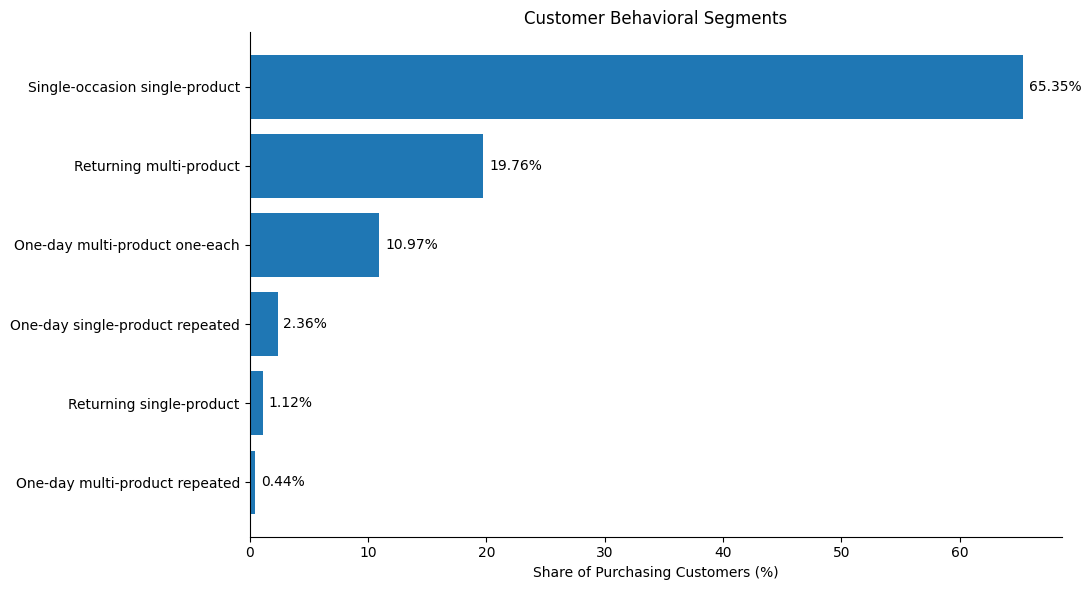

In [97]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    segment_plot["behavior_segment"],
    segment_plot["customer_pct"]
)

ax.set_title(
    "Customer Behavioral Segments"
)

ax.set_xlabel(
    "Share of Purchasing Customers (%)"
)

ax.set_ylabel("")

for bar, pct in zip(
    bars,
    segment_plot["customer_pct"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Key Takeaway

The purchasing customer base is dominated by **single-occasion single-product customers**, who represent **65.35%** of all purchasing customers.

The second-largest segment is **returning multi-product customers at 19.76%**, while the remaining segments are substantially smaller.

This reinforces the broader finding that shallow one-time purchasing dominates the observed customer base, while deeper repeat behavior is concentrated in a smaller multi-product population.

### 7.3 — Cart-to-Later-Same-SKU Purchase Outcome

This chart shows what share of unique customer-SKU cart pairs were followed by a later observed purchase of the same SKU.

The metric describes product-level cart progression and should not be interpreted as a conventional checkout conversion or cart-abandonment rate.

In [98]:
cart_conversion_pct = (
    len(valid_cart_to_purchase)
    / len(cart_pairs)
    * 100
)

no_later_purchase_pct = 100 - cart_conversion_pct

print(
    "Later same-SKU purchase:",
    round(cart_conversion_pct, 2)
)

print(
    "No later same-SKU purchase:",
    round(no_later_purchase_pct, 2)
)

Later same-SKU purchase: 20.06
No later same-SKU purchase: 79.94


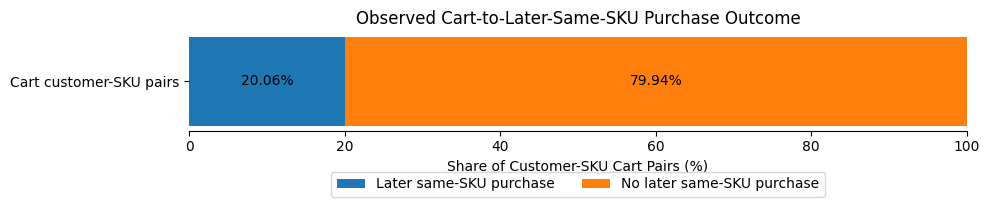

In [99]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.barh(
    ["Cart customer-SKU pairs"],
    [cart_conversion_pct],
    label="Later same-SKU purchase"
)

ax.barh(
    ["Cart customer-SKU pairs"],
    [no_later_purchase_pct],
    left=[cart_conversion_pct],
    label="No later same-SKU purchase"
)

ax.text(
    cart_conversion_pct / 2,
    0,
    f"{cart_conversion_pct:.2f}%",
    ha="center",
    va="center"
)

ax.text(
    cart_conversion_pct + no_later_purchase_pct / 2,
    0,
    f"{no_later_purchase_pct:.2f}%",
    ha="center",
    va="center"
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "Share of Customer-SKU Cart Pairs (%)"
)

ax.set_title(
    "Observed Cart-to-Later-Same-SKU Purchase Outcome"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### Key Takeaway

Only **20.06%** of unique customer-SKU cart pairs were followed by a later observed purchase of the same SKU.

The remaining **79.94%** had no later observed same-SKU purchase.

Earlier timing analysis showed that when progression did occur, it usually happened quickly: **78.63% of eventual converters purchased within 1 hour and 90.02% within 24 hours**.

This makes cart progression a short-timescale product problem distinct from long-term customer retention.

### 7.4 — Category-Level Conversion Opportunity

This chart compares cart volume with observed cart-to-later-same-SKU purchase rate across high-volume product categories.

The objective is to identify categories where below-benchmark conversion occurs at meaningful scale rather than prioritizing categories based only on low conversion rate.

In [100]:
top_gap_categories = (
    high_volume_categories[
        high_volume_categories["conversion_gap"] > 0
    ]
    .sort_values(
        "conversion_gap",
        ascending=False
    )
    .head(10)
)

display(
    top_gap_categories[
        [
            "category",
            "cart_pairs",
            "converted_pairs",
            "conversion_rate_pct",
            "conversion_gap"
        ]
    ]
)

,category,cart_pairs,converted_pairs,conversion_rate_pct,conversion_gap
3031,3138,54290,6766,12.46,4124
774,791,54514,7106,13.04,3829
343,354,27867,2594,9.31,2996
6132,6356,47428,6707,14.14,2807
1114,1144,25728,2571,9.99,2590
6123,6347,21555,3017,14.00,1307
2212,2285,15342,1852,12.07,1226
604,619,17460,2294,13.14,1208
37,37,26946,4246,15.76,1159
2576,2663,23565,3650,15.49,1077


In [101]:
top_gap_categories = (
    high_volume_categories[
        high_volume_categories["conversion_gap"] > 0
    ]
    .sort_values(
        "conversion_gap",
        ascending=False
    )
    .head(5)
)

display(
    top_gap_categories[
        [
            "category",
            "cart_pairs",
            "converted_pairs",
            "conversion_rate_pct",
            "conversion_gap"
        ]
    ]
)

,category,cart_pairs,converted_pairs,conversion_rate_pct,conversion_gap
3031,3138,54290,6766,12.46,4124
774,791,54514,7106,13.04,3829
343,354,27867,2594,9.31,2996
6132,6356,47428,6707,14.14,2807
1114,1144,25728,2571,9.99,2590


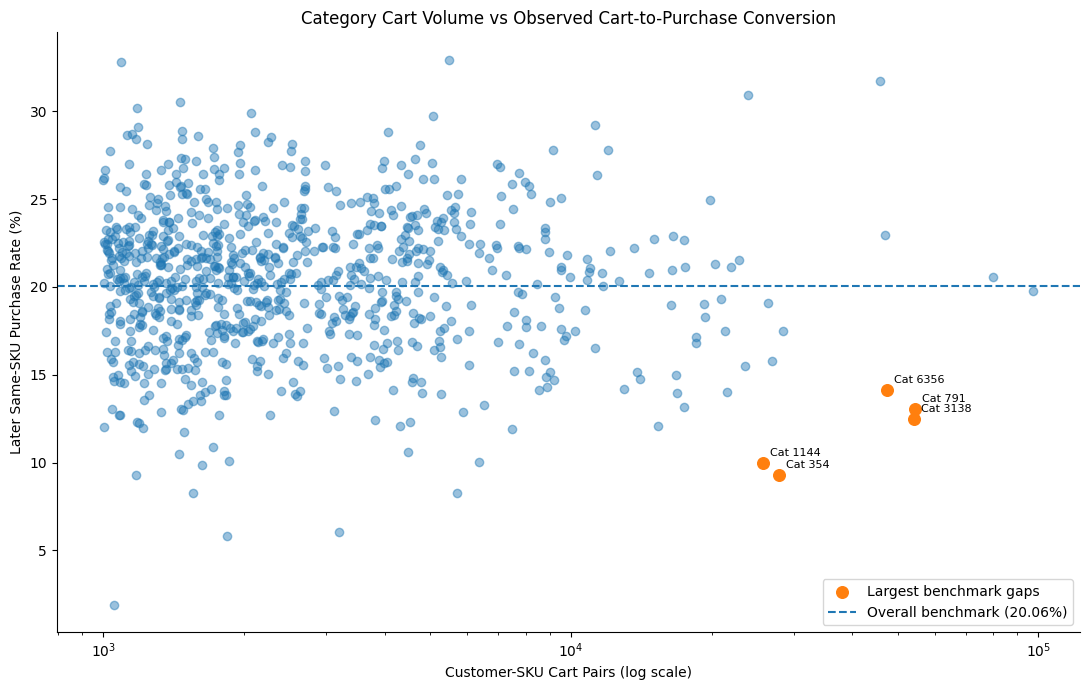

In [102]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7))

# All high-volume categories
ax.scatter(
    high_volume_categories["cart_pairs"],
    high_volume_categories["conversion_rate_pct"],
    alpha=0.45
)

# Highlight categories with the largest benchmark gaps
ax.scatter(
    top_gap_categories["cart_pairs"],
    top_gap_categories["conversion_rate_pct"],
    s=70,
    label="Largest benchmark gaps"
)

# Overall conversion benchmark
ax.axhline(
    y=overall_conversion_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall benchmark ({overall_conversion_rate:.2f}%)"
)

# Label highlighted categories
for _, row in top_gap_categories.iterrows():
    ax.annotate(
        f"Cat {int(row['category'])}",
        (
            row["cart_pairs"],
            row["conversion_rate_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xscale("log")

ax.set_title(
    "Category Cart Volume vs Observed Cart-to-Purchase Conversion"
)

ax.set_xlabel(
    "Customer-SKU Cart Pairs (log scale)"
)

ax.set_ylabel(
    "Later Same-SKU Purchase Rate (%)"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Key Takeaway

Cart-to-purchase performance varies substantially across product categories.

Several high-volume categories combine meaningful cart activity with below-benchmark conversion, suggesting that funnel investigation should consider both **scale and conversion weakness**.

Category 3138 showed the largest observed benchmark shortfall:

- **54,290 cart pairs**
- **12.46% observed conversion**
- approximately **4,124 converted pairs below the overall 20.06% benchmark**

The benchmark gap is a prioritization measure and should not be interpreted as guaranteed recoverable purchases.

### 7.5 — Weekly Cohort Retention

This heatmap shows weekly purchase retention for customers grouped by the week of their first observed purchase.

Rows represent first-purchase cohorts, while columns represent weeks since first purchase. Week 0 is excluded from the visualization so that differences in later retention are easier to see.

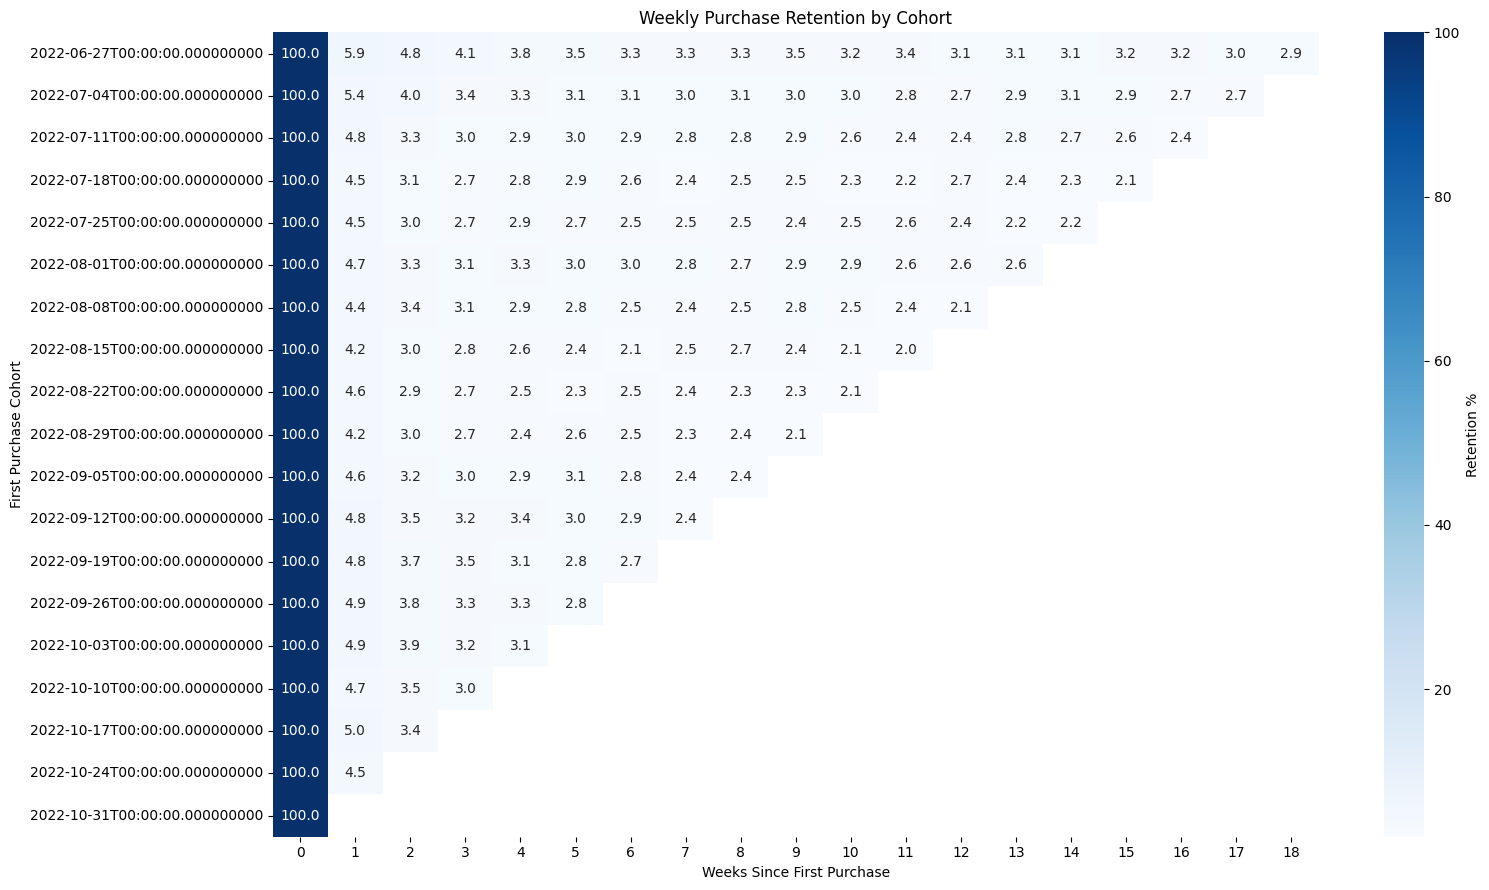

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 9))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    mask=retention_rate.isna(),
    cbar_kws={"label": "Retention %"}
)

plt.title("Weekly Purchase Retention by Cohort")
plt.xlabel("Weeks Since First Purchase")
plt.ylabel("First Purchase Cohort")
plt.tight_layout()
plt.show()

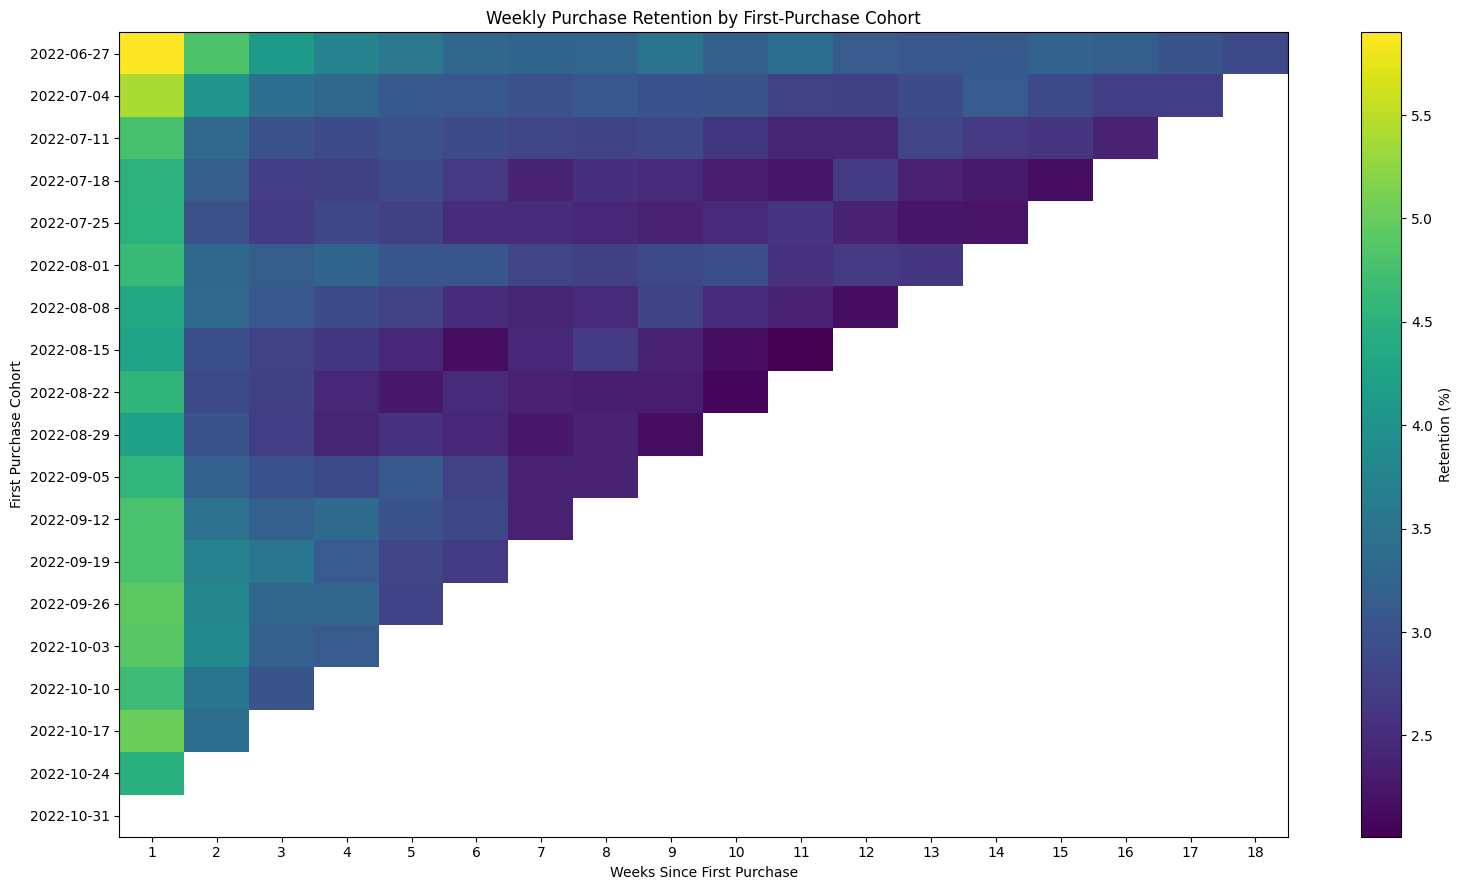

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Exclude Week 0 because it is always 100%
heatmap_data = retention_rate.loc[:, 1:].copy()

# Cleaner cohort labels
cohort_labels = [
    date.strftime("%Y-%m-%d")
    for date in heatmap_data.index
]

fig, ax = plt.subplots(figsize=(16, 9))

masked_data = np.ma.masked_invalid(
    heatmap_data.to_numpy()
)

image = ax.imshow(
    masked_data,
    aspect="auto"
)

# X-axis
ax.set_xticks(
    np.arange(len(heatmap_data.columns))
)
ax.set_xticklabels(
    heatmap_data.columns
)

# Y-axis
ax.set_yticks(
    np.arange(len(cohort_labels))
)
ax.set_yticklabels(
    cohort_labels
)

ax.set_title(
    "Weekly Purchase Retention by First-Purchase Cohort"
)

ax.set_xlabel(
    "Weeks Since First Purchase"
)

ax.set_ylabel(
    "First Purchase Cohort"
)

colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Retention (%)"
)

plt.tight_layout()
plt.show()

### Key Takeaway

Weekly purchase retention declines most sharply during the early post-purchase lifecycle and then gradually stabilizes at a smaller recurring base.

Among the seven cohorts with at least 12 weeks of observable history:

- Week 1: **4.89%**
- Week 2: **3.59%**
- Week 4: **3.11%**
- Week 8: **2.78%**
- Week 12: **2.61%**

The largest decline occurred between Week 1 and Week 2, reinforcing the importance of investigating early second-purchase activation.

Blank cells represent future periods that were not observable for newer cohorts, not zero retention.

### 7.6 — Returning-Customer Behavioral Depth

This chart compares the median observed purchase span of returning single-product and returning multi-product customers.

Purchase span measures the number of days between a customer's first and last observed purchase and provides one view of the depth of the observed purchasing relationship.

In [105]:
returning_span_plot = (
    segment_profile[
        segment_profile["behavior_segment"].isin([
            "Returning single-product",
            "Returning multi-product"
        ])
    ][
        [
            "behavior_segment",
            "median_purchase_span_days"
        ]
    ]
    .sort_values(
        "median_purchase_span_days",
        ascending=True
    )
    .copy()
)

display(returning_span_plot)

,behavior_segment,median_purchase_span_days
4,Returning single-product,6.0
3,Returning multi-product,39.0


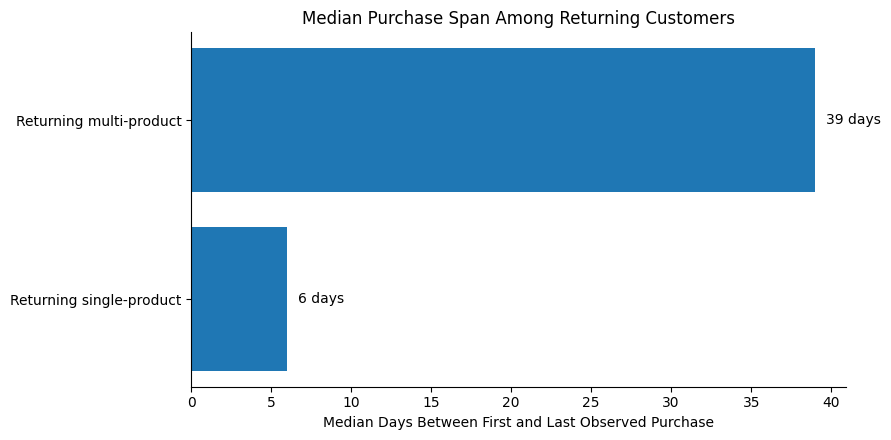

In [106]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.barh(
    returning_span_plot["behavior_segment"],
    returning_span_plot["median_purchase_span_days"]
)

for bar, value in zip(
    bars,
    returning_span_plot["median_purchase_span_days"]
):
    ax.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f} days",
        va="center"
    )

ax.set_title(
    "Median Purchase Span Among Returning Customers"
)

ax.set_xlabel(
    "Median Days Between First and Last Observed Purchase"
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Key Takeaway

Returning multi-product customers showed a substantially longer observed purchasing relationship than returning single-product customers.

Median purchase span was:

- **39 days** for returning multi-product customers
- **6 days** for returning single-product customers

Returning multi-product customers also demonstrated greater behavioral depth:

- Average return days: **1.8 vs 1.1**
- Average unique products: **4.3 vs 1.0**
- **98.87%** purchased at least one new SKU after their first purchase day.

These relationships are observational and do not establish that broader product purchasing causes stronger retention.

### 7.7 — Visual Story Summary

The visual analysis shows a consistent customer-lifecycle pattern:

**Customer base**  
→ **65.35%** single-occasion single-product

**Cart progression**  
→ only **20.06%** of cart customer-SKU pairs progress to a later same-SKU purchase

**Category diagnosis**  
→ conversion weakness is concentrated in several high-volume categories

**Retention**  
→ weekly purchasing activity falls most sharply early after first purchase

**Returning behavior**  
→ returning customers are overwhelmingly multi-product, with substantially longer observed purchase spans

**Product expansion**  
→ **98.87%** of returning multi-product customers adopt at least one new SKU after their first purchase day

Together, these visuals support treating cart progression, second-purchase activation, category-level funnel performance, and cross-product expansion as distinct product problems.

## Key Findings and Product Recommendations

### Key Findings

#### 1. The purchasing customer base is dominated by shallow observed behavior

Among **744,980 purchasing customers**:

- **65.35%** were single-occasion single-product customers.
- **79.12%** purchased on only one observed calendar day.
- Only **20.88%** purchased across multiple calendar days.

This indicates that repeat purchasing is concentrated in a relatively small part of the observed customer base.

---

#### 2. Cart-to-purchase progression is limited but occurs quickly when successful

Among **4,378,772 unique customer-SKU cart pairs**:

- **878,356** were followed by a later observed purchase of the same SKU.
- Observed cart-to-later-same-SKU purchase rate: **20.06%**
- No later observed same-SKU purchase: **79.94%**

Among pairs that eventually progressed:

- **78.63%** purchased within 1 hour.
- **90.02%** purchased within 24 hours.
- Median cart-to-purchase time was approximately **6.9 minutes**.

This suggests that cart progression is primarily a short-timescale problem involving immediate purchase intent.

---

#### 3. Cart-to-purchase performance varies substantially across categories

The overall observed benchmark was **20.06%**, but category-level conversion varied widely.

Some high-volume categories combined substantial cart activity with below-benchmark conversion.

For example, Category 3138 had:

- **54,290 cart pairs**
- **12.46% observed conversion**
- approximately **4,124 converted pairs below the overall benchmark**

This benchmark gap is a prioritization measure rather than a forecast of recoverable purchases.

---

#### 4. Retention declines most sharply early in the post-purchase lifecycle

Among the seven cohorts with at least 12 weeks of observable history:

- Week 1 retention: **4.89%**
- Week 2: **3.59%**
- Week 4: **3.11%**
- Week 8: **2.78%**
- Week 12: **2.61%**

The largest decline occurred between Week 1 and Week 2, followed by progressively smaller reductions.

This indicates that early second-purchase activation is an important area for further investigation.

---

#### 5. Returning behavior is strongly associated with broader product purchasing

Among **155,569 returning customers**:

- **94.62%** were returning multi-product customers.
- Only **5.38%** remained single-product customers.

Returning multi-product customers also demonstrated deeper observed behavior:

- Average unique products: **4.30**
- Average return days: **1.80**
- Median purchase span: **39 days**

Compared with returning single-product customers:

- Average unique products: **1.00**
- Average return days: **1.10**
- Median purchase span: **6 days**

---

#### 6. Product breadth usually expands after the first purchase day

Among **147,193 returning multi-product customers**:

- **98.87%** purchased at least one new SKU after their first purchase day.
- Median new products adopted later: **1**
- Mean: **2.78**

This shows that multi-product behavior among returners generally develops across later purchasing activity rather than being explained only by broad first-day purchasing.

### Product Recommendations

#### 1. Investigate high-volume, below-benchmark cart categories

Prioritize deeper investigation of categories that combine:

- meaningful cart volume,
- below-benchmark cart-to-purchase progression,
- and large benchmark conversion gaps.

This provides a more useful prioritization framework than focusing only on the categories with the lowest raw conversion rates.

---

#### 2. Test second-purchase activation during the early post-purchase period

Because most customers have only one observed purchase day and retention declines most sharply early in the lifecycle, test interventions designed to help first-time purchasers reach a second purchase.

Potential hypotheses include:

- relevant post-purchase recommendations,
- complementary-product discovery,
- appropriately timed reminders,
- improved post-purchase merchandising.

A suitable primary KPI is **30-day second-purchase rate**.

---

#### 3. Treat cart progression separately from retention

Cart progression occurs primarily within minutes or hours, while customer return behavior develops across days and weeks.

Product teams should therefore use different intervention strategies and KPIs for:

- immediate cart-to-purchase friction,
- and longer-term customer retention.

---

#### 4. Test cross-product discovery after the first purchase

Returning customers are overwhelmingly multi-product purchasers, and nearly all returning multi-product customers adopt new SKUs after their first purchase day.

Relevant complementary or personalized product discovery is therefore a reasonable hypothesis to test.

A suitable primary KPI is **new-product adoption rate**.

---

### Final Product Perspective

The analysis identifies four distinct product problems:

1. **Cart-to-purchase progression**
2. **Second-purchase activation**
3. **Category-specific funnel performance**
4. **Cross-product expansion**

These problems operate at different points in the customer lifecycle and should be evaluated using separate hypotheses, KPIs, and controlled experiments.

Because the dataset is observational, the findings identify behavioral associations and product opportunities rather than causal effects.